# Credit Card Fraud Detection Using Machine Learning

In [ ]:
# Importing the libraries
import numpy as np
from sklearn.utils import resample
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.model_selection import cross_validate
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from google.colab import files
uploaded = files.upload()
warnings.filterwarnings("ignore", message="numpy.dtype size changed")
warnings.filterwarnings("ignore", message="numpy.ufunc size changed")
import io
dataset = pd.read_csv(io.BytesIO(uploaded['creditcard.csv']))

Follow the link to Download the dataset and Extractinto project directory

https://drive.google.com/file/d/1YUiJpUcrAYWkzzYTdRI7jkJUStLrDsu3/view?usp=sharing
        

In [ ]:
import seaborn as sns
print(dataset.info())
print(dataset.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
def check_data_quality(df):
    print("Missing values per column:\n", df.isnull().sum())
    print("\nDuplicate rows:", df.duplicated().sum())


Text(0, 0.5, 'Frequency')

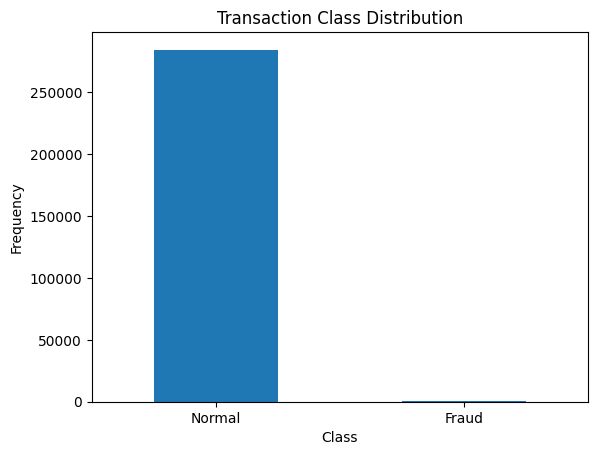

In [ ]:
Fraud = dataset[dataset['Class']==1]

Normal = dataset[dataset['Class']==0]

#count_classes = pd.value_counts(dataset['Class'], sort = True)
count_classes = pd.Series(dataset['Class']).value_counts(sort = True)

count_classes.plot(kind = 'bar', rot=0)

plt.title("Transaction Class Distribution")
LABELS = ["Normal", "Fraud"]
plt.xticks(range(2), LABELS)

plt.xlabel("Class")

plt.ylabel("Frequency")

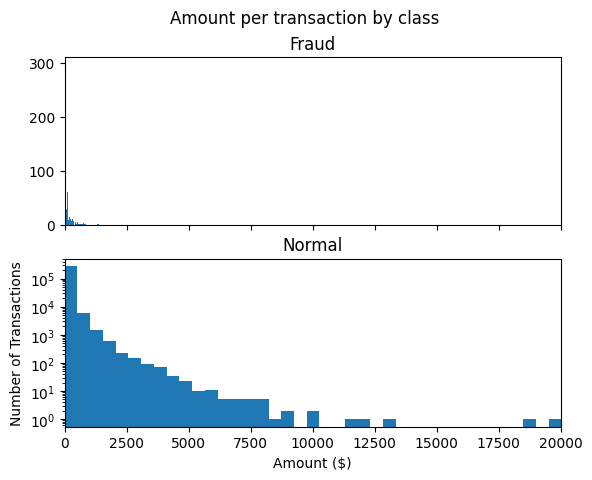

In [ ]:
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
f.suptitle('Amount per transaction by class')
bins = 50
ax1.hist(Fraud.Amount, bins = bins)
ax1.set_title('Fraud')
ax2.hist(Normal.Amount, bins = bins)
ax2.set_title('Normal')
plt.xlabel('Amount ($)')
plt.ylabel('Number of Transactions')
plt.xlim((0, 20000))
plt.yscale('log')
plt.show()

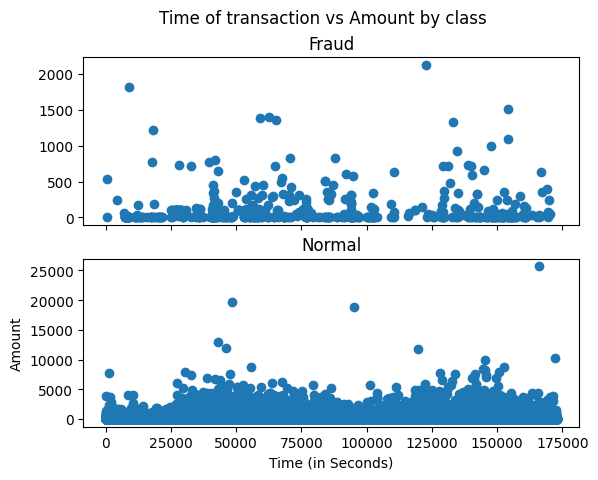

In [ ]:
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
f.suptitle('Time of transaction vs Amount by class')
ax1.scatter(Fraud.Time, Fraud.Amount)
ax1.set_title('Fraud')
ax2.scatter(Normal.Time, Normal.Amount)
ax2.set_title('Normal')
plt.xlabel('Time (in Seconds)')
plt.ylabel('Amount')
plt.show()

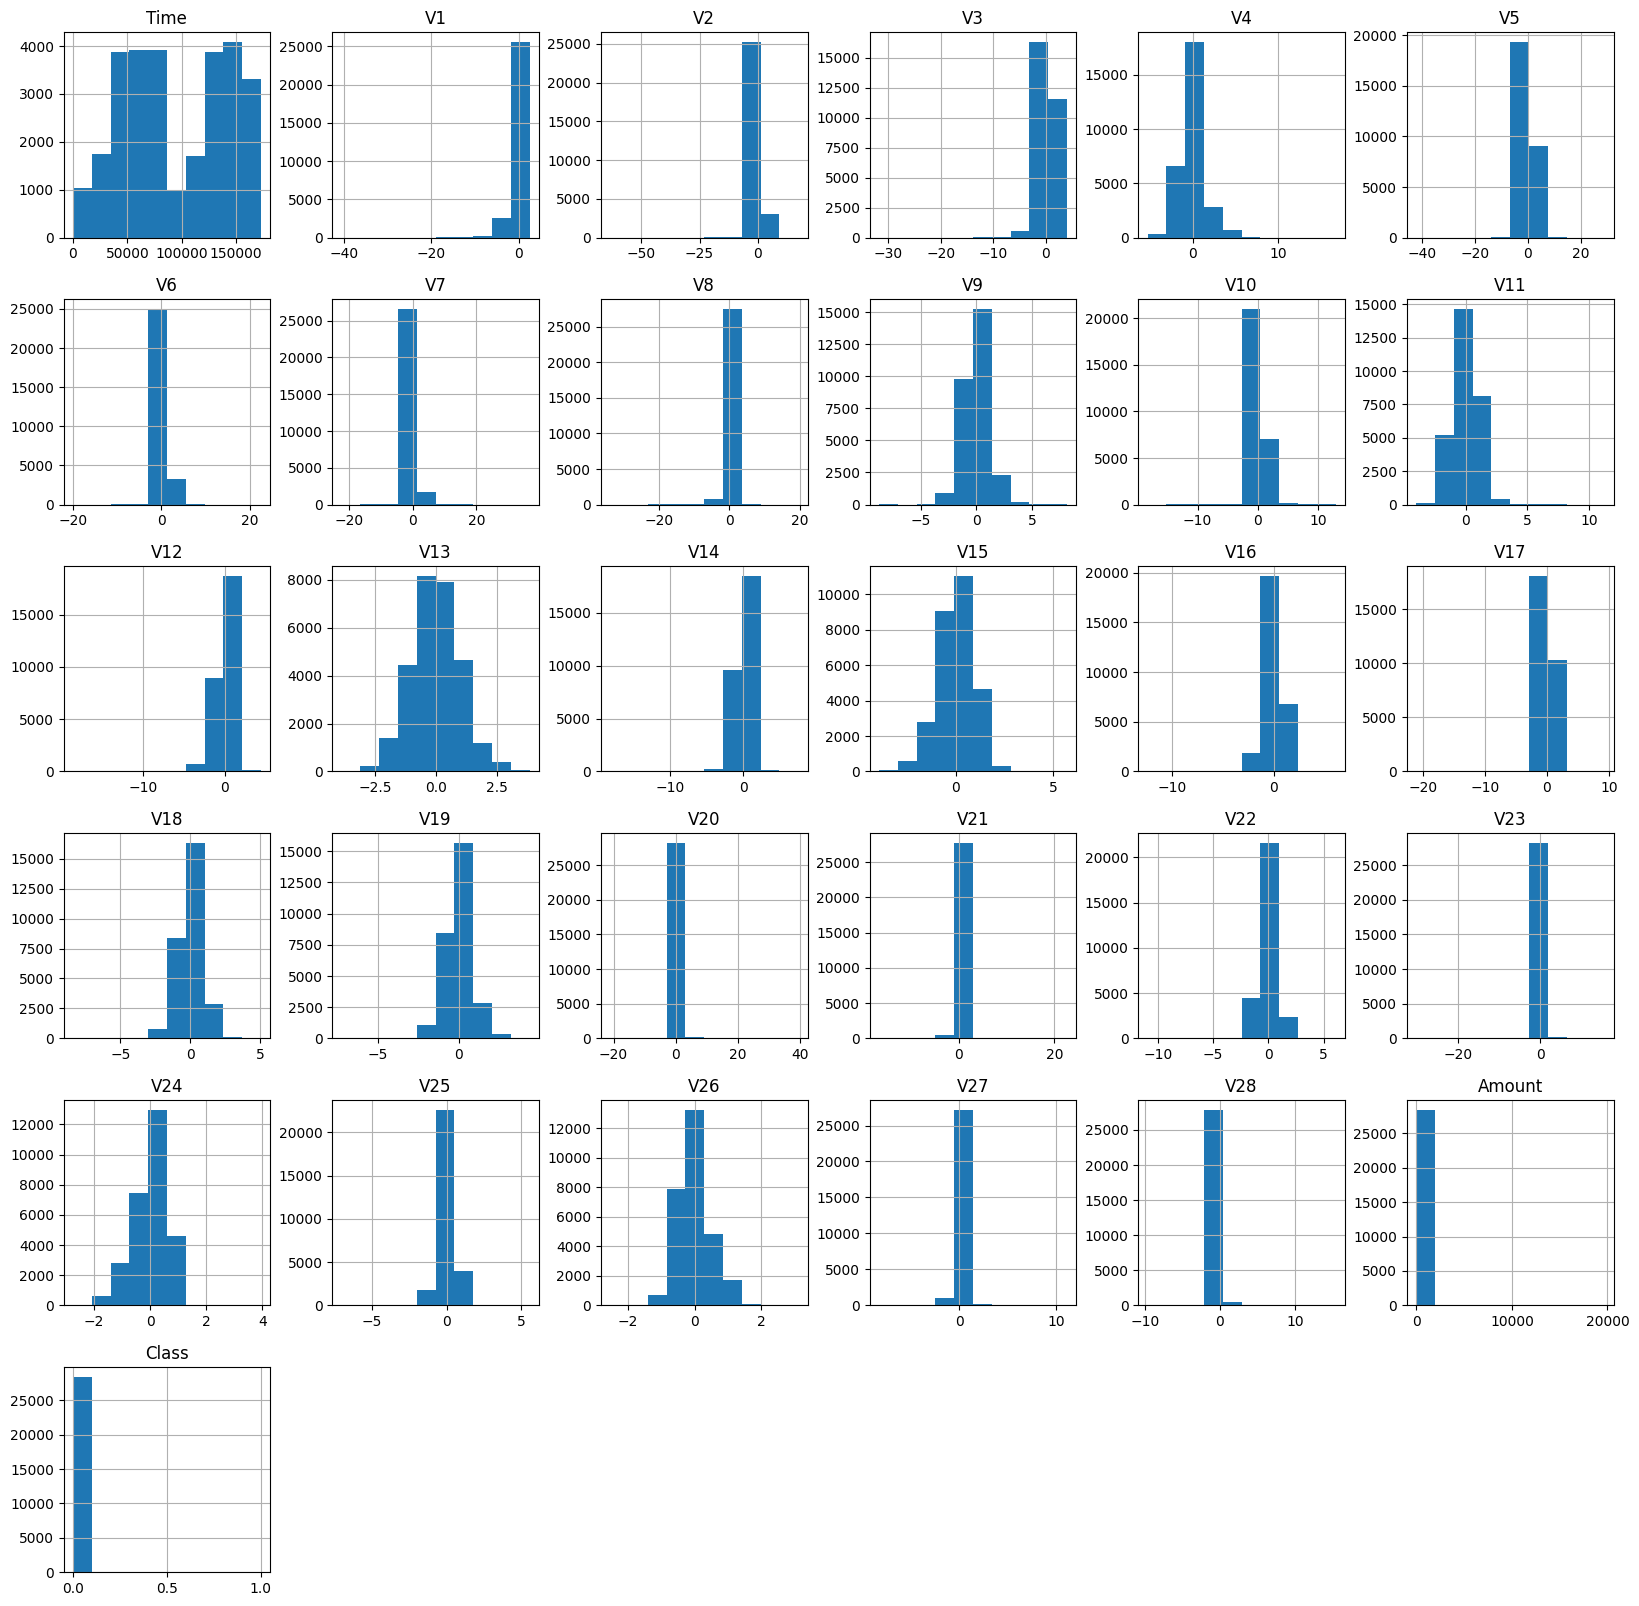

In [ ]:
data1= dataset.sample(frac = 0.1,random_state=1)
data1.hist(figsize=(20,20))
plt.show()

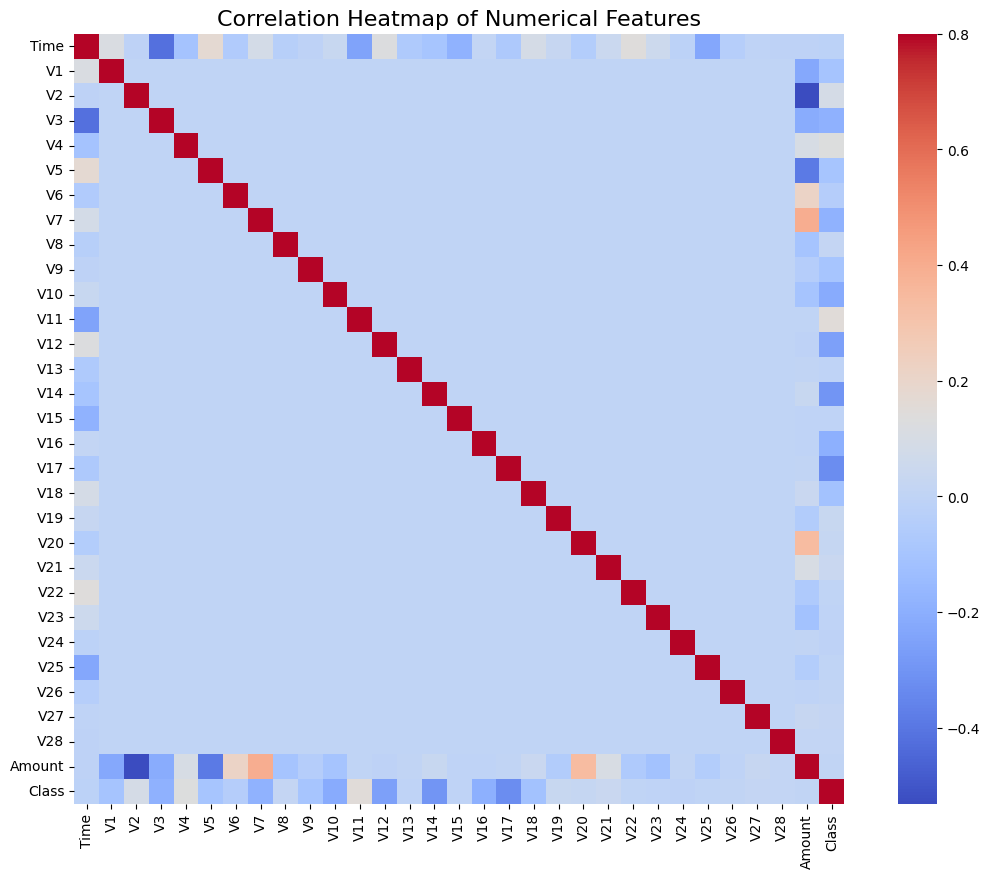

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the full correlation matrix
correlation_matrix = dataset.corr()

# Plot the heatmap
plt.figure(figsize=(14,10))
sns.heatmap(correlation_matrix, cmap='coolwarm', vmax=0.8, square=True)
plt.title("Correlation Heatmap of Numerical Features", fontsize=16)
plt.show()

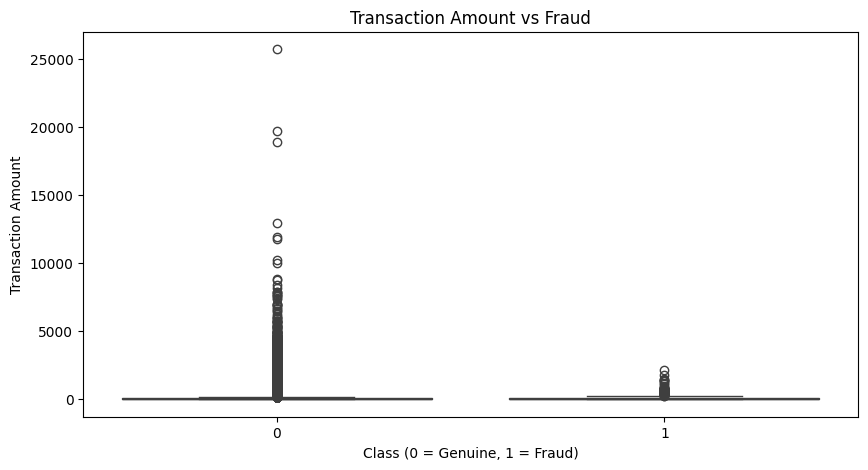

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.boxplot(x='Class', y='Amount', data=dataset)
plt.title("Transaction Amount vs Fraud")
plt.xlabel("Class (0 = Genuine, 1 = Fraud)")
plt.ylabel("Transaction Amount")
plt.show()

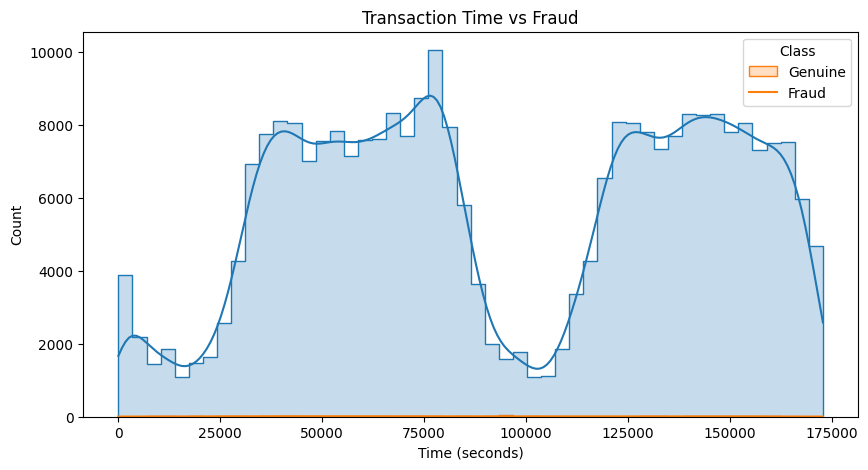

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(data=dataset, x='Time', hue='Class', bins=50, kde=True, element="step")
plt.title("Transaction Time vs Fraud")
plt.xlabel("Time (seconds)")
plt.ylabel("Count")
plt.legend(title="Class", labels=["Genuine", "Fraud"])  # Optional: if you want to rename labels correctly
plt.show()


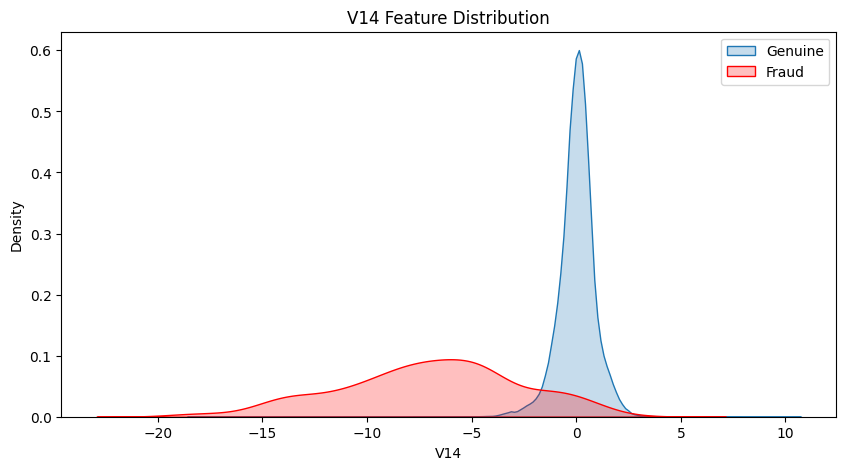

In [ ]:
plt.figure(figsize=(10,5))
sns.kdeplot(dataset[dataset['Class'] == 0]['V14'], label='Genuine', fill=True)
sns.kdeplot(dataset[dataset['Class'] == 1]['V14'], label='Fraud', fill=True, color='red')
plt.title("V14 Feature Distribution")
plt.xlabel("V14")
plt.legend()
plt.show()

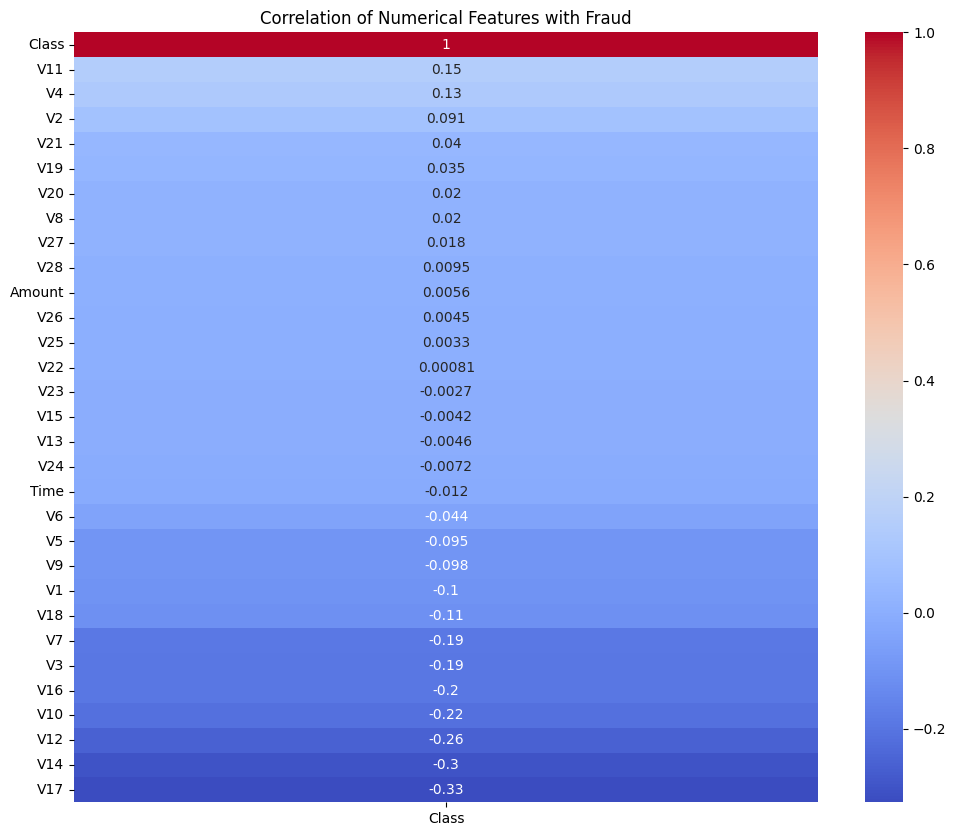

In [ ]:
import numpy as np

corr = dataset.corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr[['Class']].sort_values(by='Class', ascending=False), annot=True, cmap='coolwarm')
plt.title("Correlation of Numerical Features with Fraud")
plt.show()

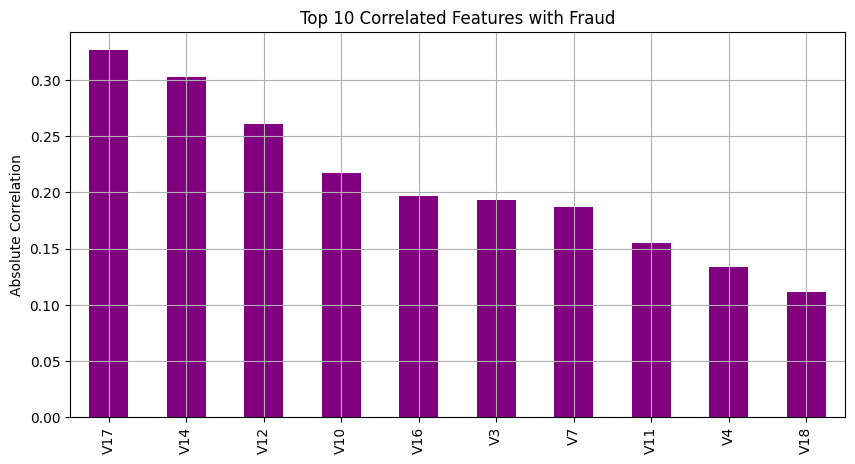

In [ ]:
top_corr = corr['Class'].abs().sort_values(ascending=False)[1:11]  # skip 'Class' itself
top_corr.plot(kind='bar', figsize=(10,5), color='purple')
plt.title("Top 10 Correlated Features with Fraud")
plt.ylabel("Absolute Correlation")
plt.grid(True)
plt.show()


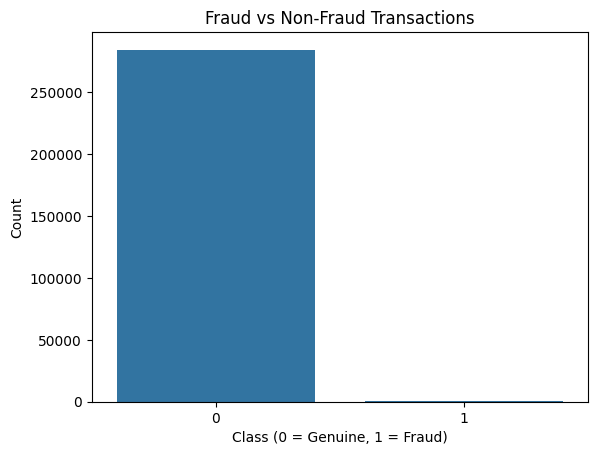

In [ ]:
sns.countplot(x='Class', data=dataset)
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Class (0 = Genuine, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

# Preprocess and splitting the dataset

In [ ]:
#X = dataset.iloc[:, [1, 29]].values
#y = dataset.iloc[:, 30].values
X = dataset.drop(columns=['Class'])
y = dataset['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,        # ✅ keeps class ratio same in train & test
    random_state=42    # ✅ use a fixed seed for reproducibility
)

# **Train models without balancing**


## Logistic Normal

=== Logistic Regression (Unbalanced) ===
Accuracy : 0.9992
Precision: 0.8289
Recall   : 0.6429
F1 Score : 0.7241
ROC AUC  : 0.9559
Confusion Matrix:
 [[56851    13]
 [   35    63]]


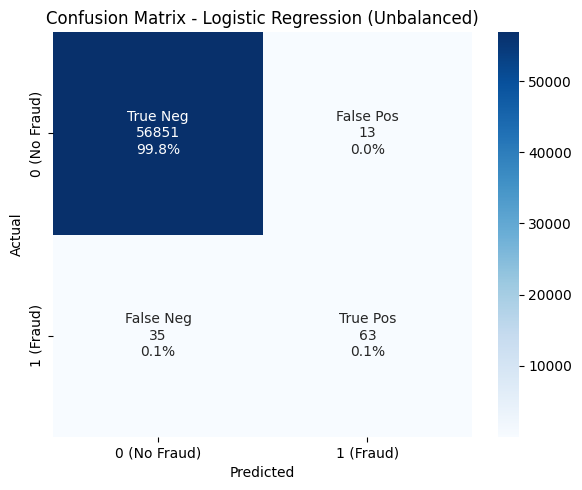

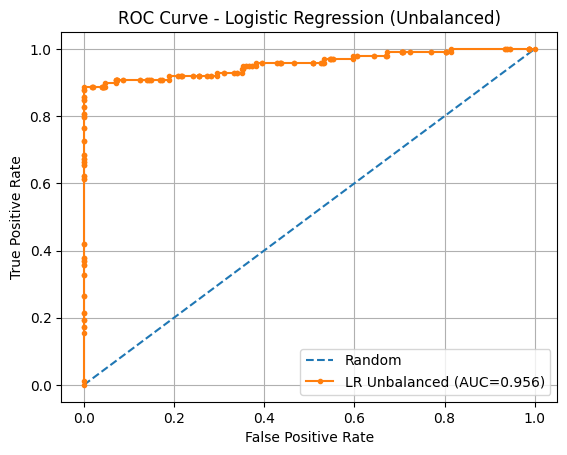

In [ ]:
# ==== Logistic Regression (UNBALANCED BASELINE) ====
# No resampling, no class_weight. Just a fair baseline.

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score, accuracy_score
)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Scale only Time & Amount (NOT a balancing step)
scale_cols = ['Time', 'Amount']
ct = ColumnTransformer(
    transformers=[('scale_num', StandardScaler(), scale_cols)],
    remainder='passthrough'
)

# Pipeline: scale(Time, Amount) -> Logistic Regression (no class_weight)
lr_unbalanced = Pipeline(steps=[
    ('scale_time_amount', ct),
    ('clf', LogisticRegression(
        random_state=42,
        max_iter=1000,
        solver='lbfgs'
    ))
])

# Train
lr_unbalanced.fit(X_train, y_train)

# Predict
y_prob = lr_unbalanced.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)   # default threshold

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1  = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_prob)
cm  = confusion_matrix(y_test, y_pred)

print("=== Logistic Regression (Unbalanced) ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {auc:.4f}")
print("Confusion Matrix:\n", cm)

# Confusion Matrix plot with labels
labels = np.array([["True Neg", "False Pos"], ["False Neg", "True Pos"]])
cm_percent = cm / np.sum(cm) * 100
annot = np.empty_like(cm).astype(str)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f"{labels[i, j]}\n{cm[i, j]}\n{cm_percent[i, j]:.1f}%"

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', cbar=True,
            xticklabels=['0 (No Fraud)', '1 (Fraud)'],
            yticklabels=['0 (No Fraud)', '1 (Fraud)'])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression (Unbalanced)")
plt.tight_layout()
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure()
plt.plot([0,1], [0,1], linestyle='--', label='Random')
plt.plot(fpr, tpr, marker='.', label=f'LR Unbalanced (AUC={auc:.3f})')
plt.title("ROC Curve - Logistic Regression (Unbalanced)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()


# Decision Tree normal

=== Decision Tree (Unbalanced) ===
Accuracy : 0.9994
Precision: 0.8462
Recall   : 0.7857
F1 Score : 0.8148
ROC AUC  : 0.9284
Confusion Matrix:
 [[56850    14]
 [   21    77]]


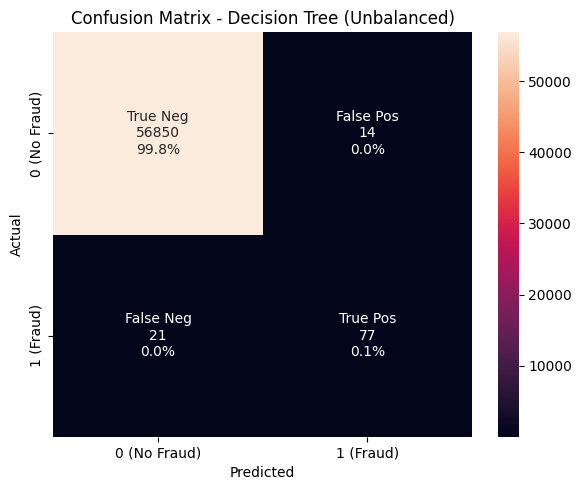

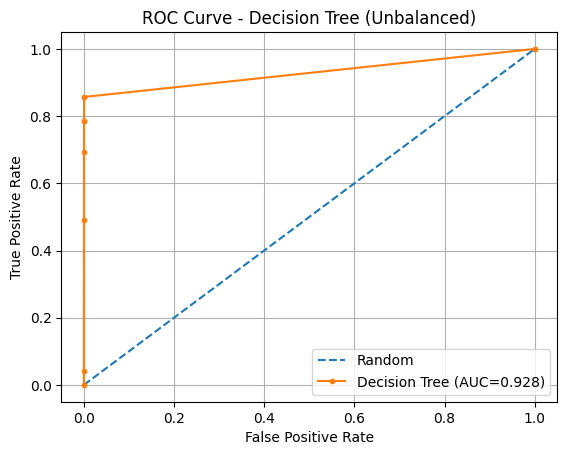

In [ ]:
# ==== Decision Tree (UNBALANCED BASELINE) ====

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score, accuracy_score
)

# Model: shallow tree (matches your report style, avoids wild overfitting)
dt_unbalanced = DecisionTreeClassifier(
    max_depth=4,            # keep shallow for baseline
    min_samples_leaf=1,
    random_state=42
)

# Train
dt_unbalanced.fit(X_train, y_train)

# Predict
y_prob = dt_unbalanced.predict_proba(X_test)[:, 1]   # probability of fraud class
y_pred = (y_prob >= 0.5).astype(int)                 # default threshold

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1  = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_prob)
cm  = confusion_matrix(y_test, y_pred)

print("=== Decision Tree (Unbalanced) ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {auc:.4f}")
print("Confusion Matrix:\n", cm)

# Confusion Matrix plot with labels
labels = np.array([["True Neg", "False Pos"], ["False Neg", "True Pos"]])
cm_percent = cm / np.sum(cm) * 100
annot = np.empty_like(cm).astype(str)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f"{labels[i, j]}\n{cm[i, j]}\n{cm_percent[i, j]:.1f}%"

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=annot, fmt='', cbar=True,
            xticklabels=['0 (No Fraud)', '1 (Fraud)'],
            yticklabels=['0 (No Fraud)', '1 (Fraud)'])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree (Unbalanced)")
plt.tight_layout()
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure()
plt.plot([0,1], [0,1], linestyle='--', label='Random')
plt.plot(fpr, tpr, marker='.', label=f'Decision Tree (AUC={auc:.3f})')
plt.title("ROC Curve - Decision Tree (Unbalanced)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()


# Random Forest normal

=== Random Forest (Unbalanced) ===
Accuracy : 0.9996
Precision: 0.9512
Recall   : 0.7959
F1 Score : 0.8667
ROC AUC  : 0.9721
Confusion Matrix:
 [[56860     4]
 [   20    78]]


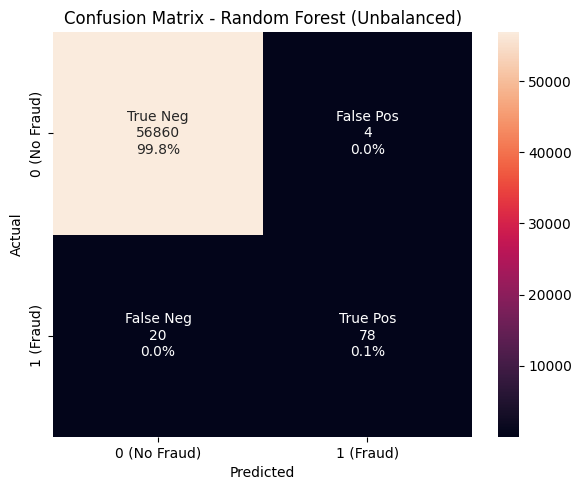

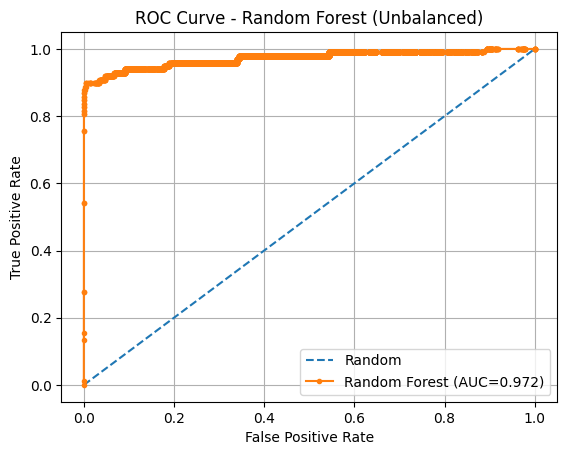

In [ ]:
# ==== Random Forest (UNBALANCED BASELINE) ====

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score, accuracy_score
)

# Model: moderate complexity to avoid wild overfitting on imbalance
rf_unbalanced = RandomForestClassifier(
    n_estimators=300,      # more trees = stabler probabilities
    max_depth=8,          # cap depth for baseline comparability
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1,            # use all cores
    class_weight=None     # <-- UNBALANCED (no weighting)
)

# Train
rf_unbalanced.fit(X_train, y_train)

# Predict
y_prob = rf_unbalanced.predict_proba(X_test)[:, 1]   # probability of fraud class
y_pred = (y_prob >= 0.5).astype(int)                 # default threshold

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1  = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_prob)
cm  = confusion_matrix(y_test, y_pred)

print("=== Random Forest (Unbalanced) ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {auc:.4f}")
print("Confusion Matrix:\n", cm)

# Confusion Matrix plot with labels
labels = np.array([["True Neg", "False Pos"], ["False Neg", "True Pos"]])
cm_percent = cm / np.sum(cm) * 100
annot = np.empty_like(cm).astype(str)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f"{labels[i, j]}\n{cm[i, j]}\n{cm_percent[i, j]:.1f}%"

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=annot, fmt='', cbar=True,
            xticklabels=['0 (No Fraud)', '1 (Fraud)'],
            yticklabels=['0 (No Fraud)', '1 (Fraud)'])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest (Unbalanced)")
plt.tight_layout()
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure()
plt.plot([0,1], [0,1], linestyle='--', label='Random')
plt.plot(fpr, tpr, marker='.', label=f'Random Forest (AUC={auc:.3f})')
plt.title("ROC Curve - Random Forest (Unbalanced)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()


# Xgboost normal

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [07:03:26] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Saved: xgb_unbalanced.joblib
=== XGBoost (Unbalanced) ===
Accuracy : 0.9994
Precision: 0.8667
Recall   : 0.7959
F1 Score : 0.8298
ROC AUC  : 0.9390
Confusion Matrix:
 [[56852    12]
 [   20    78]]


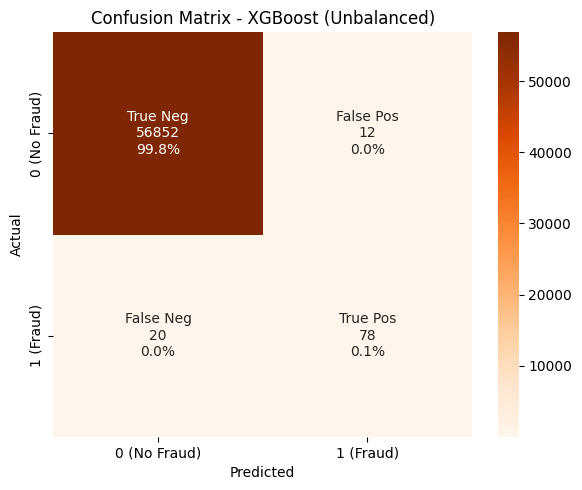

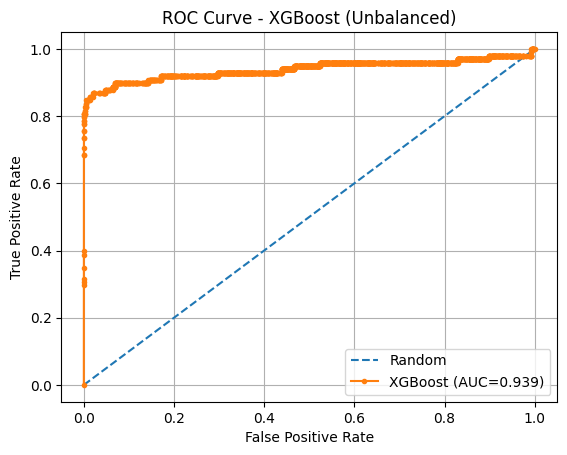

In [ ]:
# ==== XGBoost (UNBALANCED BASELINE) ====

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score, accuracy_score
)

# Model: XGBoost baseline
xgb_unbalanced = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# Train
xgb_unbalanced.fit(X_train, y_train)
import joblib
joblib.dump(xgb_unbalanced, "xgb_unbalanced.joblib")
print("Saved: xgb_unbalanced.joblib")

# Predict
y_prob = xgb_unbalanced.predict_proba(X_test)[:, 1]   # probability of fraud class
y_pred = (y_prob >= 0.5).astype(int)                  # default threshold 0.5

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1  = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_prob)
cm  = confusion_matrix(y_test, y_pred)

print("=== XGBoost (Unbalanced) ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {auc:.4f}")
print("Confusion Matrix:\n", cm)

# Confusion Matrix plot with labels
labels = np.array([["True Neg", "False Pos"], ["False Neg", "True Pos"]])
cm_percent = cm / np.sum(cm) * 100
annot = np.empty_like(cm).astype(str)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f"{labels[i, j]}\n{cm[i, j]}\n{cm_percent[i, j]:.1f}%"

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=annot, fmt='', cmap='Oranges', cbar=True,
            xticklabels=['0 (No Fraud)', '1 (Fraud)'],
            yticklabels=['0 (No Fraud)', '1 (Fraud)'])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost (Unbalanced)")
plt.tight_layout()
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure()
plt.plot([0,1], [0,1], linestyle='--', label='Random')
plt.plot(fpr, tpr, marker='.', label=f'XGBoost (AUC={auc:.3f})')
plt.title("ROC Curve - XGBoost (Unbalanced)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()


## KNN

=== K-Nearest Neighbors (Unbalanced) ===
Accuracy : 0.9983
Precision: 1.0000
Recall   : 0.0306
F1 Score : 0.0594
ROC AUC  : 0.6364
Confusion Matrix:
 [[56864     0]
 [   95     3]]


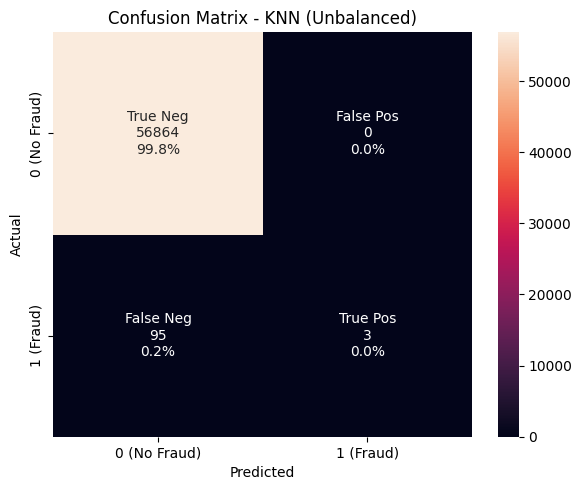

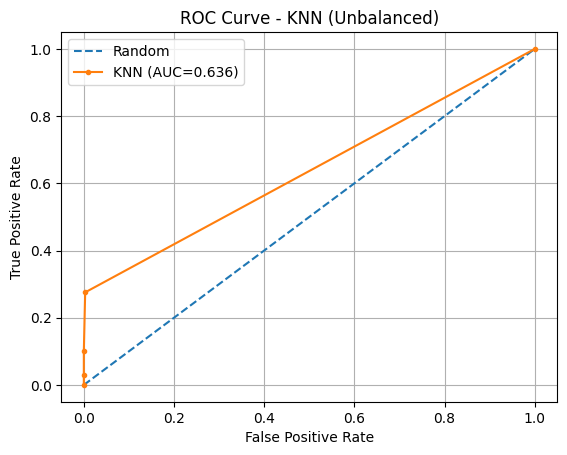

In [ ]:
# ==== K-Nearest Neighbors (UNBALANCED BASELINE) ====

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score, accuracy_score
)

# Model: KNN baseline
knn_unbalanced = KNeighborsClassifier(
    n_neighbors=5,    # standard choice
    metric='minkowski',
    p=2               # Euclidean distance
)

# Train
knn_unbalanced.fit(X_train, y_train)

# Predict
y_prob = knn_unbalanced.predict_proba(X_test)[:, 1]   # probability of fraud class
y_pred = (y_prob >= 0.5).astype(int)                  # default threshold

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)
auc  = roc_auc_score(y_test, y_prob)
cm   = confusion_matrix(y_test, y_pred)

print("=== K-Nearest Neighbors (Unbalanced) ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {auc:.4f}")
print("Confusion Matrix:\n", cm)

# Confusion Matrix plot with labels
labels = np.array([["True Neg", "False Pos"], ["False Neg", "True Pos"]])
cm_percent = cm / np.sum(cm) * 100
annot = np.empty_like(cm).astype(str)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f"{labels[i, j]}\n{cm[i, j]}\n{cm_percent[i, j]:.1f}%"

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=annot, fmt='', cbar=True,
            xticklabels=['0 (No Fraud)', '1 (Fraud)'],
            yticklabels=['0 (No Fraud)', '1 (Fraud)'])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix - KNN (Unbalanced)")
plt.tight_layout()
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure()
plt.plot([0,1], [0,1], linestyle='--', label='Random')
plt.plot(fpr, tpr, marker='.', label=f'KNN (AUC={auc:.3f})')
plt.title("ROC Curve - KNN (Unbalanced)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()


# SMOTE

In [ ]:
# ==== Train/Test Split + SMOTE (apply ONLY on training) ====

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import pandas as pd  # for easy class counts

# 1) Split the original dataset FIRST (no leakage!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# 2) Apply SMOTE on the TRAINING set only
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# 3) Inspect class distribution (before vs after)
print("Before SMOTE (train):")
print(pd.Series(y_train).value_counts().sort_index())
print("\nAfter SMOTE (train):")
print(pd.Series(y_train_resampled).value_counts().sort_index())


Before SMOTE (train):
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE (train):
Class
0    227451
1    227451
Name: count, dtype: int64


# SMOTE + LR

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy (SMOTE): 0.988
AUC (SMOTE): 0.976


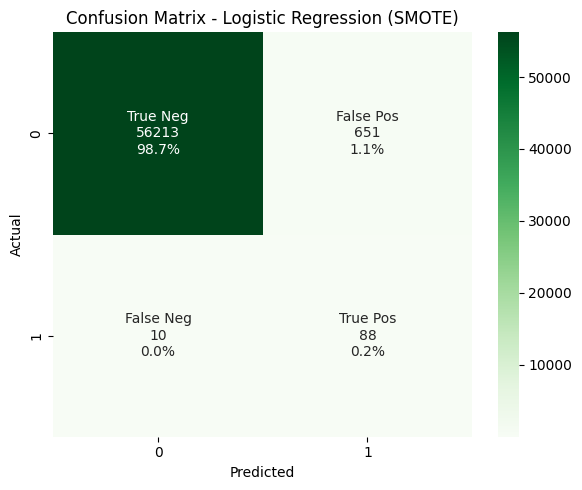

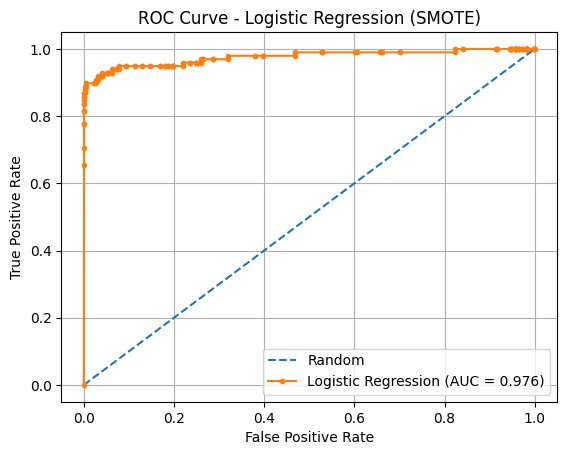

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Train Logistic Regression on SMOTE-resampled data
lr_smote = LogisticRegression(random_state=0, max_iter=1000)
lr_smote.fit(X_train_resampled, y_train_resampled)

# Predict on original test data (not oversampled)
y_pred_smote = lr_smote.predict(X_test)
probs_smote = lr_smote.predict_proba(X_test)[:, 1]

# Accuracy and AUC
acc_smote = accuracy_score(y_test, y_pred_smote)
auc_smote = roc_auc_score(y_test, probs_smote)
print("Accuracy (SMOTE): %.3f" % acc_smote)
print("AUC (SMOTE): %.3f" % auc_smote)

# Confusion Matrix
cm_smote = confusion_matrix(y_test, y_pred_smote)
labels = np.array([["True Neg", "False Pos"], ["False Neg", "True Pos"]])
cm_percent = cm_smote / np.sum(cm_smote) * 100
annot = np.empty_like(cm_smote).astype(str)

for i in range(cm_smote.shape[0]):
    for j in range(cm_smote.shape[1]):
        annot[i, j] = f"{labels[i, j]}\n{cm_smote[i, j]}\n{cm_percent[i, j]:.1f}%"

plt.figure(figsize=(6, 5))
sns.heatmap(cm_smote, annot=annot, fmt='', cmap='Greens', cbar=True,
            xticklabels=['0', '1'], yticklabels=['0', '1'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression (SMOTE)")
plt.tight_layout()
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, probs_smote)
plt.plot([0, 1], [0, 1], linestyle='--', label='Random')
plt.plot(fpr, tpr, marker='.', label=f'Logistic Regression (AUC = {auc_smote:.3f})')
plt.title("ROC Curve - Logistic Regression (SMOTE)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# ==== Hyperparameter Tuning: Logistic Regression (+ SMOTE, + Scaling) ====

import numpy as np
import pandas as pd

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    roc_auc_score, average_precision_score, confusion_matrix,
    precision_score, recall_score, f1_score, roc_curve, precision_recall_curve
)

# ----- Pipeline: Scale -> SMOTE -> Logistic Regression
pipe_lr = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("clf", LogisticRegression(solver="liblinear", max_iter=2000, random_state=42))
])

# ----- Search space (keep compact to start; expand later if needed)
param_grid = {
    "clf__penalty": ["l1", "l2"],           # liblinear supports l1/l2
    "clf__C": np.logspace(-3, 2, 10),       # 0.001 ... 100
}

# ----- CV setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ----- Grid Search optimizing ROC-AUC (good for imbalance)
gscv_lr = GridSearchCV(
    estimator=pipe_lr,
    param_grid=param_grid,
    scoring="roc_auc",      # you could also try "average_precision"
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True              # refit best model on full train set
)

# ----- Fit on the ORIGINAL (unbalanced) train split
gscv_lr.fit(X_train, y_train)

print("Best params:", gscv_lr.best_params_)
print("Best CV ROC-AUC:", round(gscv_lr.best_score_, 4))

# ===== Evaluate on untouched test set =====
best_lr = gscv_lr.best_estimator_
y_prob = best_lr.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

print("\n=== Test Metrics (Threshold=0.5) ===")
print("ROC-AUC :", round(roc_auc_score(y_test, y_prob), 4))
print("PR-AUC  :", round(average_precision_score(y_test, y_prob), 4))
print("Precision:", round(precision_score(y_test, y_pred, zero_division=0), 4))
print("Recall   :", round(recall_score(y_test, y_pred, zero_division=0), 4))
print("F1 Score :", round(f1_score(y_test, y_pred, zero_division=0), 4))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# ===== Optional: threshold tuning to target higher recall or precision =====
prec, rec, thr = precision_recall_curve(y_test, y_prob)
target_precision = 0.90  # example: keep precision >= 90%
mask = prec[:-1] >= target_precision
thr_chosen = thr[mask][np.argmax(rec[:-1][mask])] if mask.any() else thr[np.argmax(rec[:-1])]
y_pred_tuned = (y_prob >= thr_chosen).astype(int)

print(f"\nChosen threshold for ≥{int(target_precision*100)}% precision:", round(thr_chosen, 4))
print("Precision(tuned):", round(precision_score(y_test, y_pred_tuned, zero_division=0), 4))
print("Recall(tuned)   :", round(recall_score(y_test, y_pred_tuned, zero_division=0), 4))
print("F1(tuned)       :", round(f1_score(y_test, y_pred_tuned, zero_division=0), 4))
print("CM(tuned):\n", confusion_matrix(y_test, y_pred_tuned))


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'clf__C': np.float64(0.001), 'clf__penalty': 'l2'}
Best CV ROC-AUC: 0.9813

=== Test Metrics (Threshold=0.5) ===
ROC-AUC : 0.9757
PR-AUC  : 0.7373
Precision: 0.06
Recall   : 0.9184
F1 Score : 0.1127
Confusion Matrix:
 [[55455  1409]
 [    8    90]]

Chosen threshold for ≥90% precision: 1.0
Precision(tuned): 0.9167
Recall(tuned)   : 0.1122
F1(tuned)       : 0.2
CM(tuned):
 [[56863     1]
 [   87    11]]


#smote + Decision tree

In [ ]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

dt_smote_pipe = Pipeline(steps=[
    ("smote", SMOTE(random_state=42)),
    ("clf", DecisionTreeClassifier(max_depth=4, random_state=42))
])
dt_smote_pipe.fit(X_train, y_train)


Pipeline(steps=[('smote', SMOTE(random_state=42)),
                ('clf', DecisionTreeClassifier(max_depth=4, random_state=42))])

=== Decision Tree + SMOTE (Balanced) ===
Accuracy : 0.9824
Precision: 0.0805
Recall   : 0.8878
F1 Score : 0.1476
ROC AUC  : 0.9629
Confusion Matrix:
 [[55870   994]
 [   11    87]]


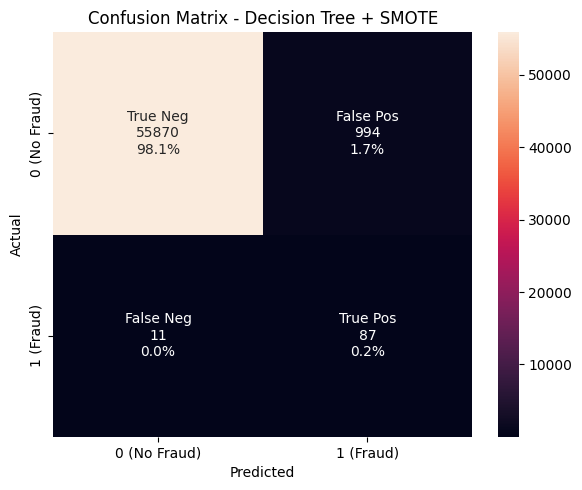

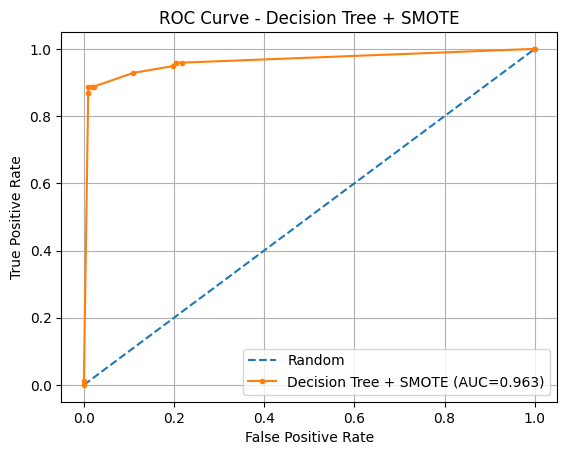

In [ ]:
# ==== Decision Tree + SMOTE (BALANCED) ====

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score, accuracy_score
)

# NOTE:
# This cell assumes you've already created:
# X_train_resampled, y_train_resampled  (via SMOTE on the training set)
# X_test, y_test                         (left UNTOUCHED / original distribution)

# Model: keep same baseline shape as unbalanced DT for fair comparison
dt_smote = DecisionTreeClassifier(
    max_depth=4,          # same as your unbalanced baseline
    min_samples_leaf=1,
    random_state=42
)

# Train on SMOTE-balanced training data
dt_smote.fit(X_train_resampled, y_train_resampled)

# Predict on untouched test set
y_prob = dt_smote.predict_proba(X_test)[:, 1]   # probability of fraud class
y_pred = (y_prob >= 0.5).astype(int)            # default threshold

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)
auc  = roc_auc_score(y_test, y_prob)
cm   = confusion_matrix(y_test, y_pred)

print("=== Decision Tree + SMOTE (Balanced) ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {auc:.4f}")
print("Confusion Matrix:\n", cm)

# Confusion Matrix plot with labels
labels = np.array([["True Neg", "False Pos"], ["False Neg", "True Pos"]])
cm_percent = cm / np.sum(cm) * 100
annot = np.empty_like(cm).astype(str)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f"{labels[i, j]}\n{cm[i, j]}\n{cm_percent[i, j]:.1f}%"

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=annot, fmt='', cbar=True,
            xticklabels=['0 (No Fraud)', '1 (Fraud)'],
            yticklabels=['0 (No Fraud)', '1 (Fraud)'])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree + SMOTE")
plt.tight_layout()
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure()
plt.plot([0,1], [0,1], linestyle='--', label='Random')
plt.plot(fpr, tpr, marker='.', label=f'Decision Tree + SMOTE (AUC={auc:.3f})')
plt.title("ROC Curve - Decision Tree + SMOTE")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()


#oversampling+Random Forest

=== Random Forest + SMOTE (Balanced) ===
Accuracy : 0.9970
Precision: 0.3494
Recall   : 0.8878
F1 Score : 0.5014
ROC AUC  : 0.9826
Confusion Matrix:
 [[56702   162]
 [   11    87]]


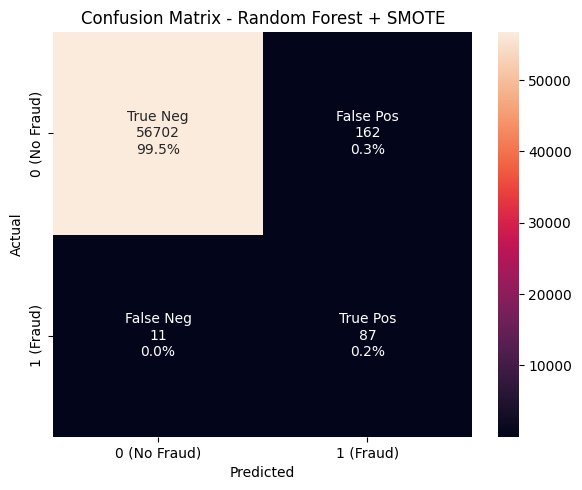

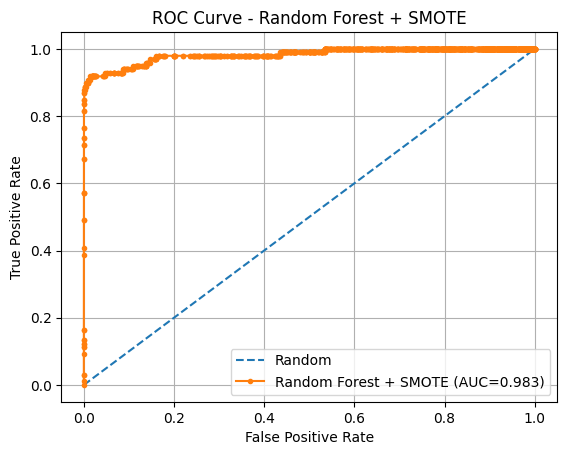

In [ ]:
# ==== Random Forest + SMOTE (BALANCED) ====

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score, accuracy_score
)

# NOTE:
# This assumes you already created:
# X_train_resampled, y_train_resampled   (via SMOTE)
# X_test, y_test                         (untouched original test set)

# Model: Random Forest (same shape as unbalanced baseline for comparison)
rf_smote = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

# Train on SMOTE-resampled data
rf_smote.fit(X_train_resampled, y_train_resampled)

# Predict on untouched test set
y_prob = rf_smote.predict_proba(X_test)[:, 1]   # probability of fraud class
y_pred = (y_prob >= 0.5).astype(int)

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)
auc  = roc_auc_score(y_test, y_prob)
cm   = confusion_matrix(y_test, y_pred)

print("=== Random Forest + SMOTE (Balanced) ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {auc:.4f}")
print("Confusion Matrix:\n", cm)

# Confusion Matrix plot with labels
labels = np.array([["True Neg", "False Pos"], ["False Neg", "True Pos"]])
cm_percent = cm / np.sum(cm) * 100
annot = np.empty_like(cm).astype(str)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f"{labels[i, j]}\n{cm[i, j]}\n{cm_percent[i, j]:.1f}%"

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=annot, fmt='', cbar=True,
            xticklabels=['0 (No Fraud)', '1 (Fraud)'],
            yticklabels=['0 (No Fraud)', '1 (Fraud)'])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest + SMOTE")
plt.tight_layout()
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure()
plt.plot([0,1], [0,1], linestyle='--', label='Random')
plt.plot(fpr, tpr, marker='.', label=f'Random Forest + SMOTE (AUC={auc:.3f})')
plt.title("ROC Curve - Random Forest + SMOTE")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()


# smote + Xgboost

1.   List item
2.   List item



Saved: xgb_smote.joblib
=== XGBoost + SMOTE (Balanced) ===
Accuracy : 0.9981
Precision: 0.4699
Recall   : 0.8776
F1 Score : 0.6121
ROC AUC  : 0.9821
Confusion Matrix:
 [[56767    97]
 [   12    86]]


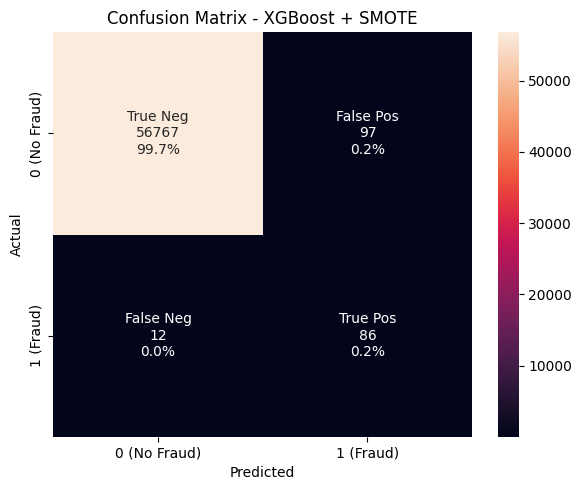

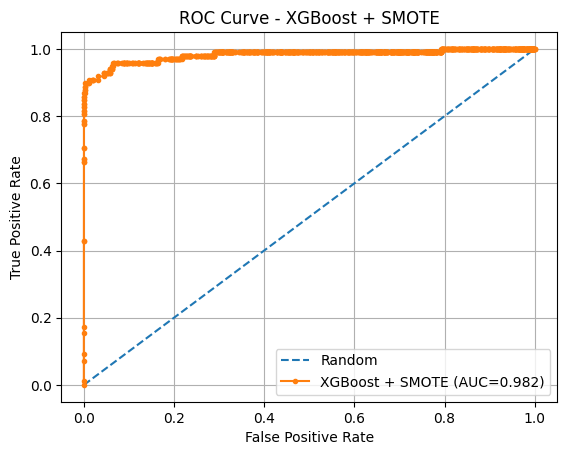

In [ ]:
# ==== XGBoost + SMOTE (BALANCED) ====

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score, accuracy_score
)

# NOTE:
# Assumes you already have:
# X_train_resampled, y_train_resampled  (SMOTE-applied training set)
# X_test, y_test                        (untouched/original distribution)

# Model: same shape as your unbalanced baseline, but trained on SMOTE data
xgb_smote = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
    eval_metric="logloss"
    # NOTE: no scale_pos_weight here since SMOTE already balances classes
)

# Train
xgb_smote.fit(X_train_resampled, y_train_resampled)
import joblib
joblib.dump(xgb_smote, "xgb_smote.joblib")
print("Saved: xgb_smote.joblib")


# Predict on untouched test set
y_prob = xgb_smote.predict_proba(X_test)[:, 1]   # probability of fraud class
y_pred = (y_prob >= 0.5).astype(int)

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)
auc  = roc_auc_score(y_test, y_prob)
cm   = confusion_matrix(y_test, y_pred)

print("=== XGBoost + SMOTE (Balanced) ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {auc:.4f}")
print("Confusion Matrix:\n", cm)

# Confusion Matrix plot with labels
labels = np.array([["True Neg", "False Pos"], ["False Neg", "True Pos"]])
cm_percent = cm / np.sum(cm) * 100
annot = np.empty_like(cm).astype(str)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f"{labels[i, j]}\n{cm[i, j]}\n{cm_percent[i, j]:.1f}%"

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=annot, fmt='', cbar=True,
            xticklabels=['0 (No Fraud)', '1 (Fraud)'],
            yticklabels=['0 (No Fraud)', '1 (Fraud)'])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost + SMOTE")
plt.tight_layout()
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure()
plt.plot([0,1], [0,1], linestyle='--', label='Random')
plt.plot(fpr, tpr, marker='.', label=f'XGBoost + SMOTE (AUC={auc:.3f})')
plt.title("ROC Curve - XGBoost + SMOTE")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()


# oversampling


In [ ]:
# ==== Random Over-Sampling (Balance Training Data) ====

from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
import pandas as pd

# 1) Split first (avoid leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 2) Apply RandomOverSampler ONLY on the training set
ros = RandomOverSampler(random_state=42)  # duplicates minority samples
X_train_over, y_train_over = ros.fit_resample(X_train, y_train)

# 3) Inspect class distribution
print("Before Over-Sampling (train):")
print(pd.Series(y_train).value_counts().sort_index())
print("\nAfter Over-Sampling (train):")
print(pd.Series(y_train_over).value_counts().sort_index())


Before Over-Sampling (train):
Class
0    227451
1       394
Name: count, dtype: int64

After Over-Sampling (train):
Class
0    227451
1    227451
Name: count, dtype: int64


# oversampling+LR

=== Logistic Regression + RandomOverSampler (Balanced) ===
Accuracy : 0.9758
Precision: 0.0616
Recall   : 0.9184
F1 Score : 0.1155
ROC AUC  : 0.9720
Confusion Matrix:
 [[55494  1370]
 [    8    90]]


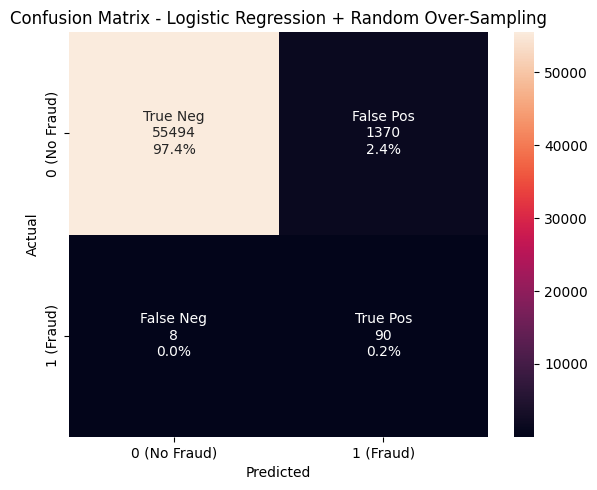

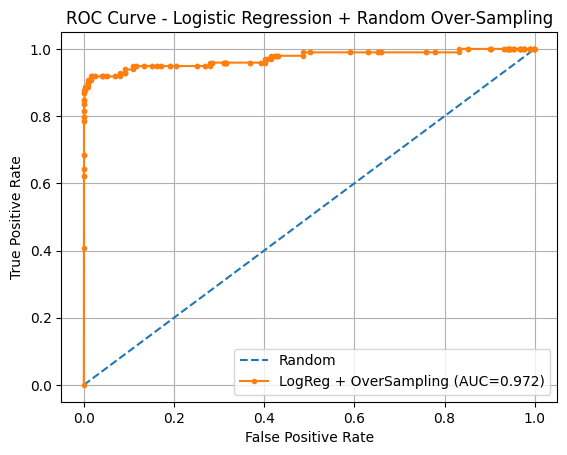

In [ ]:
# ==== Logistic Regression + Random Over-Sampling (BALANCED) ====

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import RandomOverSampler
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score, accuracy_score
)

# 1) Apply Random Over-Sampling on training set
ros = RandomOverSampler(random_state=42)
X_train_over, y_train_over = ros.fit_resample(X_train, y_train)

# 2) Scale (important for LR)
scaler = StandardScaler()
X_train_over_scaled = scaler.fit_transform(X_train_over)
X_test_scaled = scaler.transform(X_test)

# 3) Train Logistic Regression
lr_over = LogisticRegression(
    solver="liblinear",
    random_state=42,
    max_iter=1000
)
lr_over.fit(X_train_over_scaled, y_train_over)

# 4) Predict
y_prob = lr_over.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

# 5) Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)
auc  = roc_auc_score(y_test, y_prob)
cm   = confusion_matrix(y_test, y_pred)

print("=== Logistic Regression + RandomOverSampler (Balanced) ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {auc:.4f}")
print("Confusion Matrix:\n", cm)

# 6) Confusion Matrix plot with labels
labels = np.array([["True Neg", "False Pos"], ["False Neg", "True Pos"]])
cm_percent = cm / np.sum(cm) * 100
annot = np.empty_like(cm).astype(str)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f"{labels[i, j]}\n{cm[i, j]}\n{cm_percent[i, j]:.1f}%"

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=annot, fmt='', cbar=True,
            xticklabels=['0 (No Fraud)', '1 (Fraud)'],
            yticklabels=['0 (No Fraud)', '1 (Fraud)'])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression + Random Over-Sampling")
plt.tight_layout()
plt.show()

# 7) ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure()
plt.plot([0,1], [0,1], linestyle='--', label='Random')
plt.plot(fpr, tpr, marker='.', label=f'LogReg + OverSampling (AUC={auc:.3f})')
plt.title("ROC Curve - Logistic Regression + Random Over-Sampling")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()


# Undersampling+Decision tree

=== Decision Tree (depth=4) + RandomOverSampler (Balanced) ===
Accuracy : 0.9517
Precision: 0.0305
Recall   : 0.8776
F1 Score : 0.0589
ROC AUC  : 0.9280
Confusion Matrix:
 [[54126  2738]
 [   12    86]]


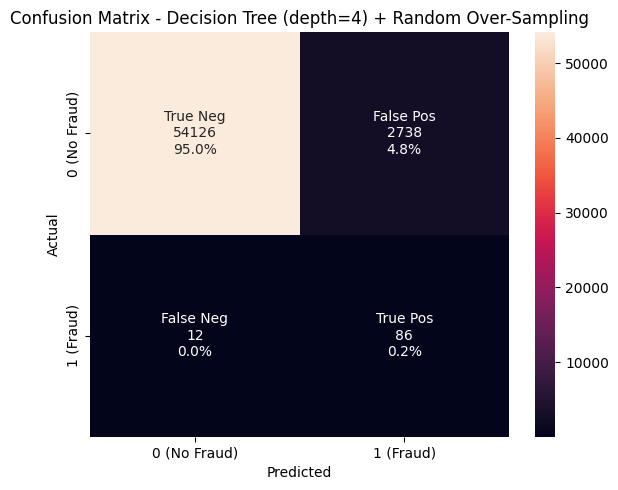

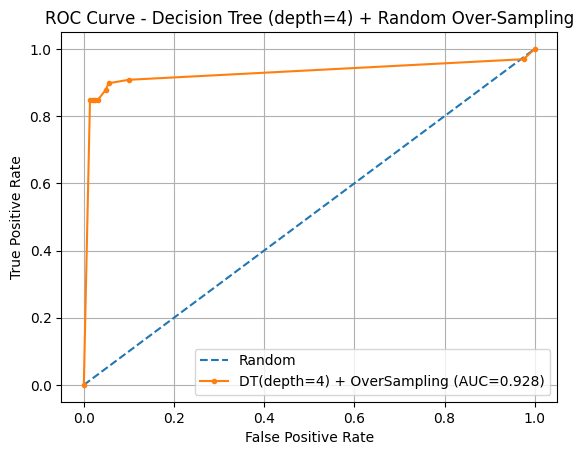

In [ ]:
# ==== Decision Tree + Random Over-Sampling (BALANCED, depth=4) ====

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import RandomOverSampler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score, accuracy_score
)

# 1) Random Over-Sampling on TRAIN only
ros = RandomOverSampler(random_state=42)
X_train_over, y_train_over = ros.fit_resample(X_train, y_train)

# 2) Model: Decision Tree (depth=4 to match your baseline style)
dt_over = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=1,
    random_state=42
)

# 3) Train
dt_over.fit(X_train_over, y_train_over)

# 4) Predict on untouched test set
y_prob = dt_over.predict_proba(X_test)[:, 1]   # probability of fraud class
y_pred = (y_prob >= 0.5).astype(int)

# 5) Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)
auc  = roc_auc_score(y_test, y_prob)
cm   = confusion_matrix(y_test, y_pred)

print("=== Decision Tree (depth=4) + RandomOverSampler (Balanced) ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {auc:.4f}")
print("Confusion Matrix:\n", cm)

# 6) Confusion Matrix heatmap with labels
labels = np.array([["True Neg", "False Pos"], ["False Neg", "True Pos"]])
cm_percent = cm / np.sum(cm) * 100
annot = np.empty_like(cm).astype(str)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f"{labels[i, j]}\n{cm[i, j]}\n{cm_percent[i, j]:.1f}%"

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=annot, fmt='', cbar=True,
            xticklabels=['0 (No Fraud)', '1 (Fraud)'],
            yticklabels=['0 (No Fraud)', '1 (Fraud)'])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree (depth=4) + Random Over-Sampling")
plt.tight_layout()
plt.show()

# 7) ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure()
plt.plot([0,1], [0,1], linestyle='--', label='Random')
plt.plot(fpr, tpr, marker='.', label=f'DT(depth=4) + OverSampling (AUC={auc:.3f})')
plt.title("ROC Curve - Decision Tree (depth=4) + Random Over-Sampling")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()


# oversampling+Random Forest

=== Random Forest + RandomOverSampler (Balanced) ===
Accuracy : 0.9984
Precision: 0.5185
Recall   : 0.8571
F1 Score : 0.6462
ROC AUC  : 0.9811
Confusion Matrix:
 [[56786    78]
 [   14    84]]


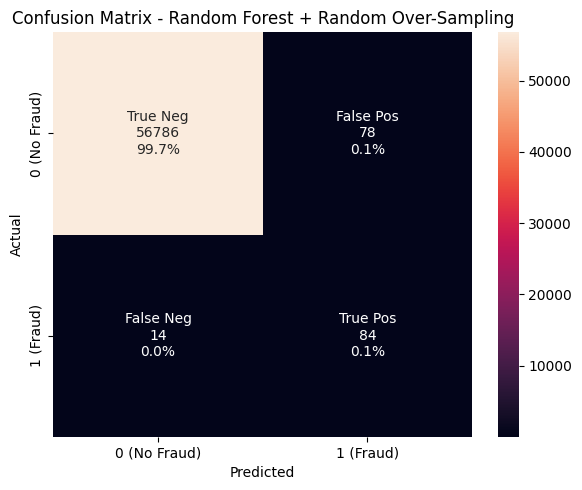

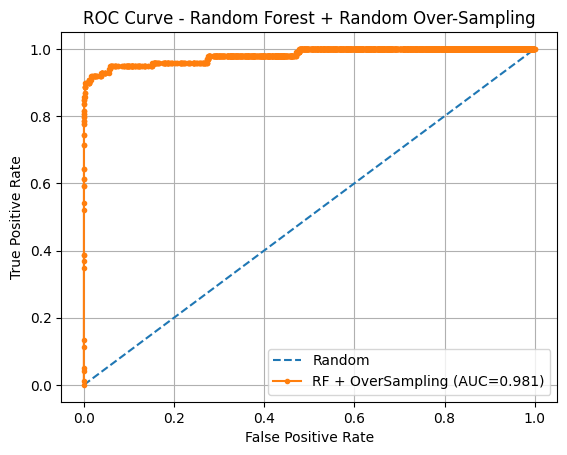

In [ ]:
# ==== Random Forest + Random Over-Sampling (BALANCED) ====

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import RandomOverSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score, accuracy_score
)

# 1) Apply Random Over-Sampling on training set only
ros = RandomOverSampler(random_state=42)
X_train_over, y_train_over = ros.fit_resample(X_train, y_train)

# 2) Model: Random Forest (same setup as unbalanced baseline)
rf_over = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

# 3) Train
rf_over.fit(X_train_over, y_train_over)

# 4) Predict on untouched test set
y_prob = rf_over.predict_proba(X_test)[:, 1]   # probability of fraud class
y_pred = (y_prob >= 0.5).astype(int)

# 5) Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)
auc  = roc_auc_score(y_test, y_prob)
cm   = confusion_matrix(y_test, y_pred)

print("=== Random Forest + RandomOverSampler (Balanced) ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {auc:.4f}")
print("Confusion Matrix:\n", cm)

# 6) Confusion Matrix plot with labels
labels = np.array([["True Neg", "False Pos"], ["False Neg", "True Pos"]])
cm_percent = cm / np.sum(cm) * 100
annot = np.empty_like(cm).astype(str)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f"{labels[i, j]}\n{cm[i, j]}\n{cm_percent[i, j]:.1f}%"

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=annot, fmt='', cbar=True,
            xticklabels=['0 (No Fraud)', '1 (Fraud)'],
            yticklabels=['0 (No Fraud)', '1 (Fraud)'])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest + Random Over-Sampling")
plt.tight_layout()
plt.show()

# 7) ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure()
plt.plot([0,1], [0,1], linestyle='--', label='Random')
plt.plot(fpr, tpr, marker='.', label=f'RF + OverSampling (AUC={auc:.3f})')
plt.title("ROC Curve - Random Forest + Random Over-Sampling")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()


=== Random Forest + RandomOverSampler (Balanced) ===
Accuracy : 0.9984
Precision: 0.5185
Recall   : 0.8571
F1 Score : 0.6462
ROC AUC  : 0.9811
Confusion Matrix:
 [[56786    78]
 [   14    84]]


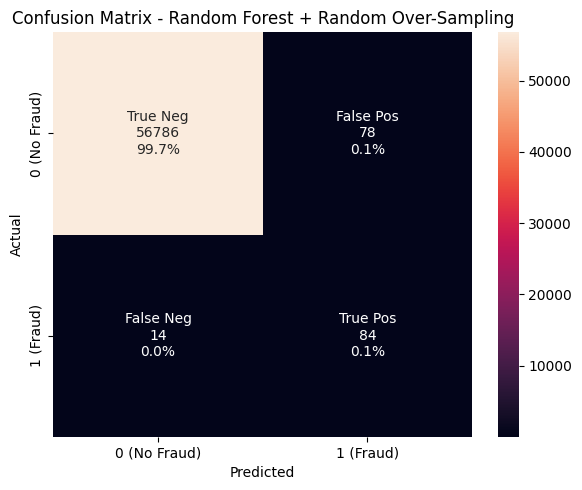

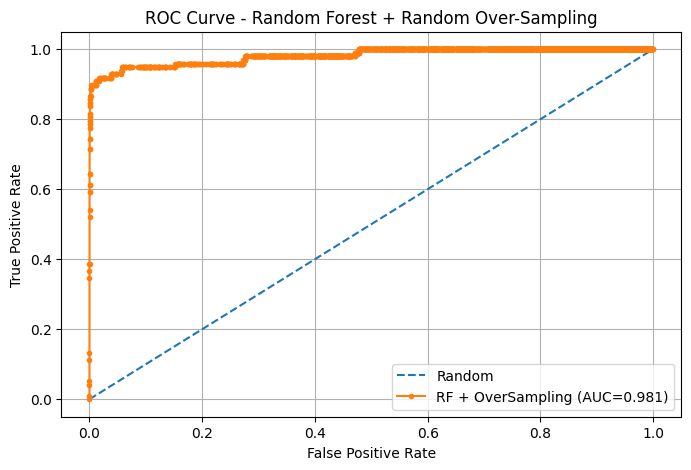


Top 10 Features - Random Forest (with Random Oversampling):
   Feature  Importance
14     V14    0.176275
4       V4    0.126160
10     V10    0.123922
12     V12    0.107064
17     V17    0.080094
11     V11    0.068073
3       V3    0.057775
16     V16    0.054876
2       V2    0.027018
7       V7    0.026338


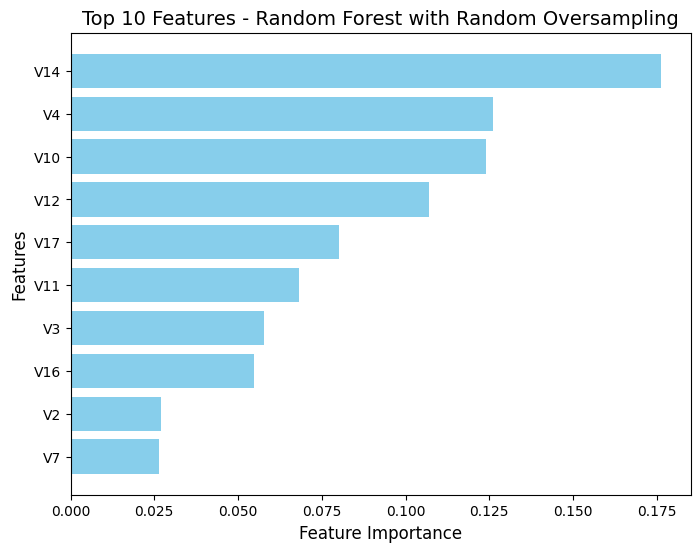

In [ ]:
# ==== Random Forest + Random Over-Sampling (BALANCED) ====

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import RandomOverSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score, accuracy_score
)

# 1) Apply Random Over-Sampling on training set only
ros = RandomOverSampler(random_state=42)
X_train_over, y_train_over = ros.fit_resample(X_train, y_train)

# 2) Model: Random Forest (same setup as unbalanced baseline)
rf_over = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

# 3) Train
rf_over.fit(X_train_over, y_train_over)

# 4) Predict on untouched test set
y_prob = rf_over.predict_proba(X_test)[:, 1]   # probability of fraud class
y_pred = (y_prob >= 0.5).astype(int)

# 5) Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)
auc  = roc_auc_score(y_test, y_prob)
cm   = confusion_matrix(y_test, y_pred)

print("=== Random Forest + RandomOverSampler (Balanced) ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {auc:.4f}")
print("Confusion Matrix:\n", cm)

# 6) Confusion Matrix plot with labels
labels = np.array([["True Neg", "False Pos"], ["False Neg", "True Pos"]])
cm_percent = cm / np.sum(cm) * 100
annot = np.empty_like(cm).astype(str)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f"{labels[i, j]}\n{cm[i, j]}\n{cm_percent[i, j]:.1f}%"

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=annot, fmt='', cbar=True,
            xticklabels=['0 (No Fraud)', '1 (Fraud)'],
            yticklabels=['0 (No Fraud)', '1 (Fraud)'])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest + Random Over-Sampling")
plt.tight_layout()
plt.show()

# 7) ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure()
plt.plot([0,1], [0,1], linestyle='--', label='Random')
plt.plot(fpr, tpr, marker='.', label=f'RF + OverSampling (AUC={auc:.3f})')
plt.title("ROC Curve - Random Forest + Random Over-Sampling")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

# 8) Top Feature Importances
import pandas as pd

importances = rf_over.feature_importances_
feature_names = X_train.columns  # use training feature names

feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\nTop 10 Features - Random Forest (with Random Oversampling):")
print(feat_imp.head(10))

# Plot Top 10
top_features = feat_imp.head(10)
plt.figure(figsize=(8,6))
plt.barh(top_features["Feature"], top_features["Importance"], color="skyblue")
plt.gca().invert_yaxis()
plt.title("Top 10 Features - Random Forest with Random Oversampling", fontsize=14)
plt.xlabel("Feature Importance", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.show()


# oversampling + Xgboost normal

Saved: xgb_ros.joblib
=== XGBoost + RandomOverSampler (Balanced) ===
Accuracy : 0.9989
Precision: 0.6316
Recall   : 0.8571
F1 Score : 0.7273
ROC AUC  : 0.9843
Confusion Matrix:
 [[56815    49]
 [   14    84]]


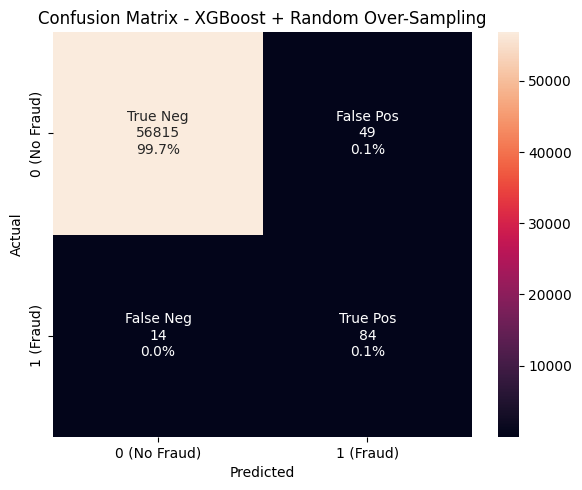

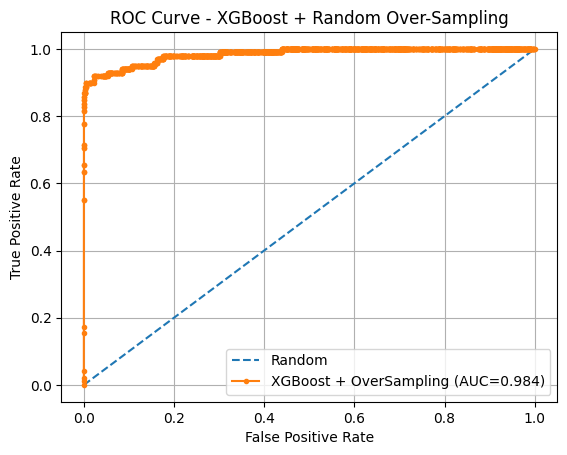

In [ ]:
# ==== XGBoost + Random Over-Sampling (BALANCED) ====

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import RandomOverSampler
from xgboost import XGBClassifier
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score, accuracy_score
)

# 1) Apply Random Over-Sampling on TRAIN only
ros = RandomOverSampler(random_state=42)
X_train_over, y_train_over = ros.fit_resample(X_train, y_train)

# 2) Model: same baseline shape as your unbalanced XGB (no class weighting)
xgb_ros = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
    eval_metric="logloss"
    # NOTE: no scale_pos_weight because we've balanced with over-sampling
)

# 3) Train
xgb_ros.fit(X_train_over, y_train_over)
import joblib
joblib.dump(xgb_ros, "xgb_ros.joblib")
print("Saved: xgb_ros.joblib")

# 4) Predict on untouched test set
y_prob = xgb_ros.predict_proba(X_test)[:, 1]   # probability of fraud class
y_pred = (y_prob >= 0.5).astype(int)

# 5) Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)
auc  = roc_auc_score(y_test, y_prob)
cm   = confusion_matrix(y_test, y_pred)

print("=== XGBoost + RandomOverSampler (Balanced) ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {auc:.4f}")
print("Confusion Matrix:\n", cm)

# 6) Confusion Matrix plot with labels
labels = np.array([["True Neg", "False Pos"], ["False Neg", "True Pos"]])
cm_percent = cm / np.sum(cm) * 100
annot = np.empty_like(cm).astype(str)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f"{labels[i, j]}\n{cm[i, j]}\n{cm_percent[i, j]:.1f}%"

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=annot, fmt='', cbar=True,
            xticklabels=['0 (No Fraud)', '1 (Fraud)'],
            yticklabels=['0 (No Fraud)', '1 (Fraud)'])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost + Random Over-Sampling")
plt.tight_layout()
plt.show()

# 7) ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure()
plt.plot([0,1], [0,1], linestyle='--', label='Random')
plt.plot(fpr, tpr, marker='.', label=f'XGBoost + OverSampling (AUC={auc:.3f})')
plt.title("ROC Curve - XGBoost + Random Over-Sampling")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()


# oversampling+ knn

=== KNN + RandomOverSampler (Balanced) ===
Accuracy : 0.9991
Precision: 0.6864
Recall   : 0.8265
F1 Score : 0.7500
ROC AUC  : 0.9182
Confusion Matrix:
 [[56827    37]
 [   17    81]]


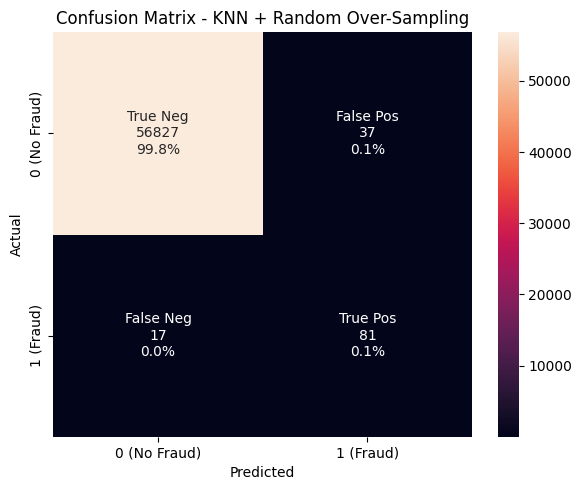

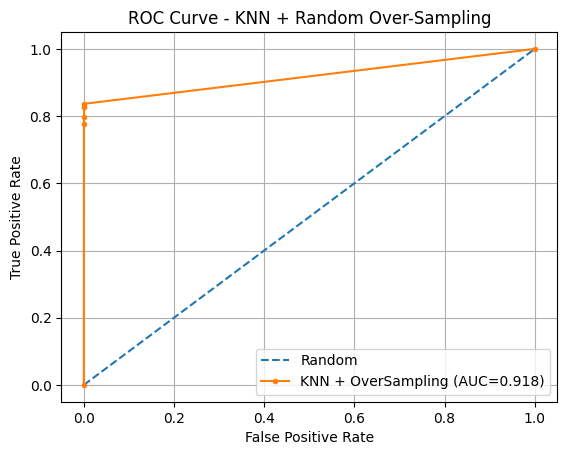

In [ ]:
# ==== K-Nearest Neighbors + Random Over-Sampling (BALANCED) ====

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import RandomOverSampler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score, accuracy_score
)

# 1) Apply Random Over-Sampling on training set only
ros = RandomOverSampler(random_state=42)
X_train_over, y_train_over = ros.fit_resample(X_train, y_train)

# 2) Scale features (important for KNN)
scaler = StandardScaler()
X_train_over_scaled = scaler.fit_transform(X_train_over)
X_test_scaled = scaler.transform(X_test)

# 3) Model: KNN
knn_over = KNeighborsClassifier(
    n_neighbors=5,
    metric='minkowski',
    p=2   # Euclidean distance
)

# 4) Train
knn_over.fit(X_train_over_scaled, y_train_over)

# 5) Predict on untouched test set
y_prob = knn_over.predict_proba(X_test_scaled)[:, 1]   # probability of fraud class
y_pred = (y_prob >= 0.5).astype(int)

# 6) Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)
auc  = roc_auc_score(y_test, y_prob)
cm   = confusion_matrix(y_test, y_pred)

print("=== KNN + RandomOverSampler (Balanced) ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {auc:.4f}")
print("Confusion Matrix:\n", cm)

# 7) Confusion Matrix plot with labels
labels = np.array([["True Neg", "False Pos"], ["False Neg", "True Pos"]])
cm_percent = cm / np.sum(cm) * 100
annot = np.empty_like(cm).astype(str)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f"{labels[i, j]}\n{cm[i, j]}\n{cm_percent[i, j]:.1f}%"

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=annot, fmt='', cbar=True,
            xticklabels=['0 (No Fraud)', '1 (Fraud)'],
            yticklabels=['0 (No Fraud)', '1 (Fraud)'])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix - KNN + Random Over-Sampling")
plt.tight_layout()
plt.show()

# 8) ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure()
plt.plot([0,1], [0,1], linestyle='--', label='Random')
plt.plot(fpr, tpr, marker='.', label=f'KNN + OverSampling (AUC={auc:.3f})')
plt.title("ROC Curve - KNN + Random Over-Sampling")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import joblib
xgb_model = joblib.load("xgb_smote.joblib")   # or any of the saved files


In [ ]:
# === Step 2: Compare Unbalanced / SMOTE / ROS XGB models ===
# Picks best by PR-AUC (Average Precision) and saves it as best_xgb.joblib

import numpy as np, pandas as pd, joblib, json
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score
)

# --- Load back saved models ---
xgb_unbalanced = joblib.load("xgb_unbalanced.joblib")
xgb_smote      = joblib.load("xgb_smote.joblib")
xgb_ros        = joblib.load("xgb_ros.joblib")

# --- Collect models in a dictionary ---
models = {
    "xgb_unbalanced": xgb_unbalanced,
    "xgb_smote":      xgb_smote,
    "xgb_ros":        xgb_ros
}

# --- Ensure test data is in DataFrame format ---
X_test_df = X_test if isinstance(X_test, pd.DataFrame) else pd.DataFrame(X_test)

def eval_model(model, X, y, thr=0.5):
    proba = model.predict_proba(X)[:, 1]
    pred  = (proba >= thr).astype(int)
    return {
        "ROC_AUC": roc_auc_score(y, proba),
        "PR_AUC":  average_precision_score(y, proba),  # a.k.a. AP
        "Precision@0.5": precision_score(y, pred, zero_division=0),
        "Recall@0.5":    recall_score(y, pred, zero_division=0),
        "F1@0.5":        f1_score(y, pred, zero_division=0),
    }

# --- Evaluate all models ---
rows = []
for name, model in models.items():
    metrics = eval_model(model, X_test_df, y_test, thr=0.5)
    metrics["Model"] = name
    rows.append(metrics)

df = pd.DataFrame(rows).set_index("Model").sort_values("PR_AUC", ascending=False)
print("=== Test-set comparison (higher is better) ===")
display(df)

# --- Select winner by PR-AUC (you can change to ROC_AUC if needed) ---
best_name  = df.index[0]
best_model = models[best_name]
print(f"\n[SELECTED] Best model by PR-AUC: {best_name}")

# --- Save artifacts ---
joblib.dump(best_model, "best_xgb.joblib")
df.to_csv("xgb_model_comparison_test_metrics.csv", index=True)

with open("best_xgb_meta.json", "w") as f:
    json.dump({"best_model_name": best_name}, f)

print("\n[SAVED]")
print(" - best_xgb.joblib   <-- winner")
print(" - xgb_model_comparison_test_metrics.csv (for your report)")
print(" - best_xgb_meta.json (records winner's name)")


=== Test-set comparison (higher is better) ===


,ROC_AUC,PR_AUC,Precision@0.5,Recall@0.5,F1@0.5
Model,,,,,
xgb_smote,0.982121,0.856148,0.469945,0.877551,0.612100
xgb_ros,0.984262,0.853885,0.631579,0.857143,0.727273
xgb_unbalanced,0.938952,0.797291,0.866667,0.795918,0.829787



[SELECTED] Best model by PR-AUC: xgb_smote

[SAVED]
 - best_xgb.joblib   <-- winner
 - xgb_model_comparison_test_metrics.csv (for your report)
 - best_xgb_meta.json (records winner's name)


In [ ]:
# === Step 3: Threshold tuning for the best XGBoost model ===
import numpy as np, json, joblib
from sklearn.metrics import fbeta_score, precision_recall_curve, confusion_matrix, classification_report

# 1) Load the winner from Step 2
best_model = joblib.load("best_xgb.joblib")

# Ensure X_test is a DataFrame
import pandas as pd
X_test_df = X_test if isinstance(X_test, pd.DataFrame) else pd.DataFrame(X_test)

# 2) Get predicted probabilities for fraud
proba = best_model.predict_proba(X_test_df)[:, 1]

# 3) Search thresholds from 0.01 to 0.99
candidates = np.linspace(0.01, 0.99, 99)

def pick_threshold(beta=2.0):
    """Pick threshold that maximizes F-beta (beta=2 favors recall)"""
    best_t, best_f = 0.5, -1
    for t in candidates:
        pred = (proba >= t).astype(int)
        f = fbeta_score(y_test, pred, beta=beta, zero_division=0)
        if f > best_f:
            best_f, best_t = f, t
    return best_t, best_f

# 4) Get best thresholds
t_f2, f2 = pick_threshold(beta=2.0)  # prioritize recall
t_f1, f1 = pick_threshold(beta=1.0)  # balance

print(f"Best F2 threshold: {t_f2:.3f} (F2={f2:.3f})")
print(f"Best F1 threshold: {t_f1:.3f} (F1={f1:.3f})")

# 5) Choose one (usually F2 for fraud detection to maximize recall)
chosen_threshold = float(t_f2)

# 6) Evaluate at chosen threshold
y_pred = (proba >= chosen_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix @ chosen threshold:\n", cm)
print("\nClassification report @ chosen threshold:\n", classification_report(y_test, y_pred, zero_division=0))

# 7) Save the chosen threshold for deployment
with open("best_xgb_threshold.json", "w") as f:
    json.dump({"threshold": chosen_threshold}, f)

print(f"\nSaved threshold to best_xgb_threshold.json (value={chosen_threshold:.3f})")


Best F2 threshold: 0.960 (F2=0.832)
Best F1 threshold: 0.980 (F1=0.856)

Confusion Matrix @ chosen threshold:
 [[56850    14]
 [   17    81]]

Classification report @ chosen threshold:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.83      0.84        98

    accuracy                           1.00     56962
   macro avg       0.93      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962


Saved threshold to best_xgb_threshold.json (value=0.960)


In [ ]:
# ==== MODEL EXPLAINABILITY (Global + Local) ====
# Requirements: pip install shap
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

# Helper: get final estimator if it's inside a Pipeline
def get_final_estimator(model):
    if hasattr(model, "named_steps"):  # Pipeline
        # common final step names: "clf", else last step
        if "clf" in model.named_steps:
            return model.named_steps["clf"]
        # fall back to the last step
        return list(model.named_steps.values())[-1]
    return model

# ---- 0) Choose a small working subset for speed (optional) ----
X_shap = X_test.copy()
y_shap = y_test.copy()
# If your test set is huge, uncomment next line to speed up SHAP:
# X_shap = X_test.sample(n=min(3000, len(X_test)), random_state=42)

# ---- 1) Logistic Regression coefficients (global, human-readable) ----
# Works best if your tuned LR is a Pipeline like gscv_lr.best_estimator_
try:
    best_lr_pipe = gscv_lr.best_estimator_
    lr_final = get_final_estimator(best_lr_pipe)  # should be LogisticRegression
    coefs = pd.Series(lr_final.coef_.ravel(), index=X_test.columns)
    odr = np.exp(coefs)  # odds ratios

    coef_table = pd.DataFrame({
        "feature": X_test.columns,
        "coef": coefs.values,
        "odds_ratio": odr.values
    }).sort_values("coef", ascending=False)

    print("Top +ve LR features (push towards FRAUD)")
    display(coef_table.head(10))
    print("\nTop -ve LR features (push towards NON-FRAUD)")
    display(coef_table.tail(10))
except Exception as e:
    print("LR coefficients not available:", e)

# ---- 2) SHAP for tree models (RF and XGB) ----
# Random Forest (tuned)
try:
    rf_final = get_final_estimator(best_rf)  # best_rf is Pipeline(SMOTE->RF)
    expl_rf = shap.TreeExplainer(rf_final)
    shap_rf = expl_rf.shap_values(X_shap)

    print("\n[RF] Global feature importance (SHAP summary)")
    plt.figure()
    shap.summary_plot(shap_rf, X_shap, show=False)
    plt.tight_layout()
    plt.show()

    print("[RF] Local explanation (row 0)")
    exp_rf0 = shap.Explanation(values=shap_rf[0],
                               base_values=expl_rf.expected_value,
                               data=X_shap.iloc[0],
                               feature_names=X_shap.columns)
    shap.plots.waterfall(exp_rf0)
    plt.show()
except Exception as e:
    print("RF SHAP not available:", e)

# XGBoost (tuned)
try:
    xgb_final = get_final_estimator(best_xgb)  # usually already a bare estimator
    expl_xgb = shap.TreeExplainer(xgb_final)
    shap_xgb = expl_xgb.shap_values(X_shap)

    print("\n[XGB] Global feature importance (SHAP summary)")
    plt.figure()
    shap.summary_plot(shap_xgb, X_shap, show=False)
    plt.tight_layout()
    plt.show()

    print("[XGB] Local explanation (row 0)")
    exp_xgb0 = shap.Explanation(values=shap_xgb[0],
                                base_values=expl_xgb.expected_value,
                                data=X_shap.iloc[0],
                                feature_names=X_shap.columns)
    shap.plots.waterfall(exp_xgb0)
    plt.show()
except Exception as e:
    print("XGB SHAP not available:", e)

# ---- 3) Permutation importance (model-agnostic) on tuned RF (optional) ----
try:
    print("\n[RF] Permutation Importance (on X_test, scoring=roc_auc)")
    r = permutation_importance(get_final_estimator(best_rf), X_test, y_test,
                               n_repeats=5, random_state=42, scoring="roc_auc")
    pi = pd.DataFrame({
        "feature": X_test.columns,
        "importance_mean": r.importances_mean,
        "importance_std": r.importances_std
    }).sort_values("importance_mean", ascending=False)
    display(pi.head(15))
except Exception as e:
    print("Permutation importance not available:", e)


Top +ve LR features (push towards FRAUD)


,feature,coef,odds_ratio
4,V4,1.057941,2.880435
29,Amount,0.371063,1.449274
5,V5,0.353365,1.423851
1,V1,0.316417,1.372203
22,V22,0.289064,1.335177
11,V11,0.184110,1.202148
7,V7,0.114018,1.120773
28,V28,0.111565,1.118026
2,V2,0.083805,1.087417
21,V21,0.082756,1.086277



Top -ve LR features (push towards NON-FRAUD)


,feature,coef,odds_ratio
9,V9,-0.232664,0.792420
26,V26,-0.260542,0.770634
6,V6,-0.290695,0.747743
0,Time,-0.363191,0.695454
13,V13,-0.368898,0.691496
16,V16,-0.390755,0.676546
8,V8,-0.414990,0.660347
12,V12,-0.465073,0.628089
10,V10,-0.625192,0.535159
14,V14,-0.866724,0.420326


RF SHAP not available: name 'best_rf' is not defined
XGB SHAP not available: name 'best_xgb' is not defined

[RF] Permutation Importance (on X_test, scoring=roc_auc)
Permutation importance not available: name 'best_rf' is not defined


Saved table: ./Chapter4/lr_coefficients.csv


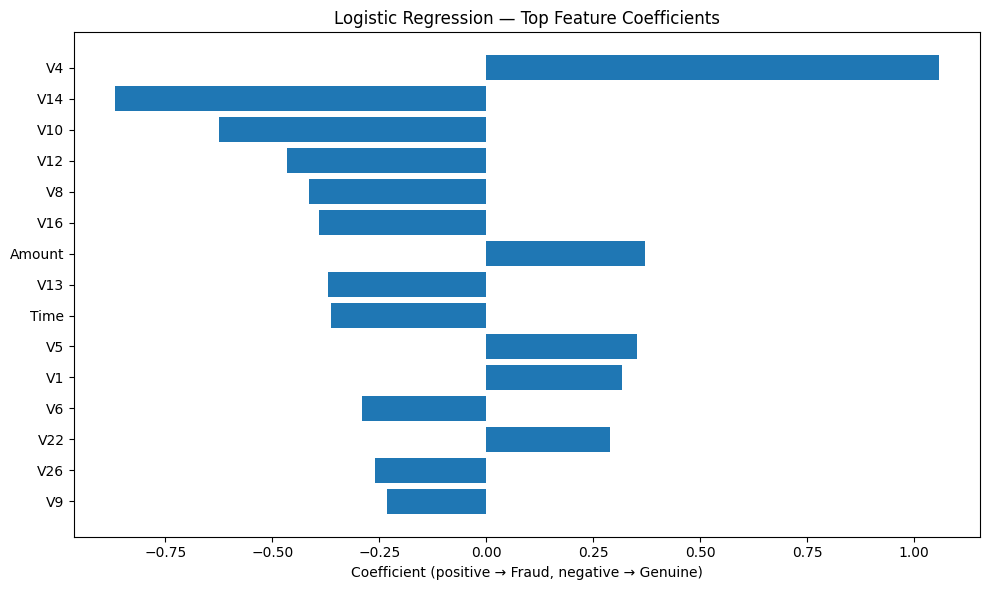

Saved figure: ./Chapter4/lr_coefficients.png


In [ ]:
# ==== Logistic Regression Coefficients → Figure + CSV ====
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUT_DIR = "./Chapter4"
os.makedirs(OUT_DIR, exist_ok=True)
IMG_PATH = f"{OUT_DIR}/lr_coefficients.png"
CSV_PATH = f"{OUT_DIR}/lr_coefficients.csv"

def get_final_estimator(model):
    """Return the classifier even if wrapped in a Pipeline."""
    if hasattr(model, "named_steps"):
        return model.named_steps.get("clf", list(model.named_steps.values())[-1])
    return model

# 1) Pull LR out of pipeline if needed
lr_final = get_final_estimator(best_lr)

# 2) Build coefficient table (coef + odds ratio)
coefs = pd.Series(lr_final.coef_.ravel(), index=X_test.columns)
odds_ratios = np.exp(coefs)

coef_table = (
    pd.DataFrame({
        "feature": X_test.columns,
        "coef": coefs.values,
        "odds_ratio": odds_ratios.values
    })
    .assign(abs_coef=lambda d: d["coef"].abs())
    .sort_values("abs_coef", ascending=False)
)

# 3) Save the full table (nice to cite in appendix)
coef_table[["feature", "coef", "odds_ratio"]].to_csv(CSV_PATH, index=False)
print("Saved table:", CSV_PATH)

# 4) Plot Top-N by |coef|
TOP_N = 15
top = coef_table.head(TOP_N).iloc[::-1]  # reverse for nice top-to-bottom order

plt.figure(figsize=(10, 6))
plt.barh(top["feature"], top["coef"])
plt.xlabel("Coefficient (positive → Fraud, negative → Genuine)")
plt.title("Logistic Regression — Top Feature Coefficients")
plt.tight_layout()
plt.savefig(IMG_PATH, dpi=200)
plt.show()

print("Saved figure:", IMG_PATH)


[INFO] Computing SHAP values… (this can take a minute on large data)


[PLOT] SHAP Feature Importance (bar)


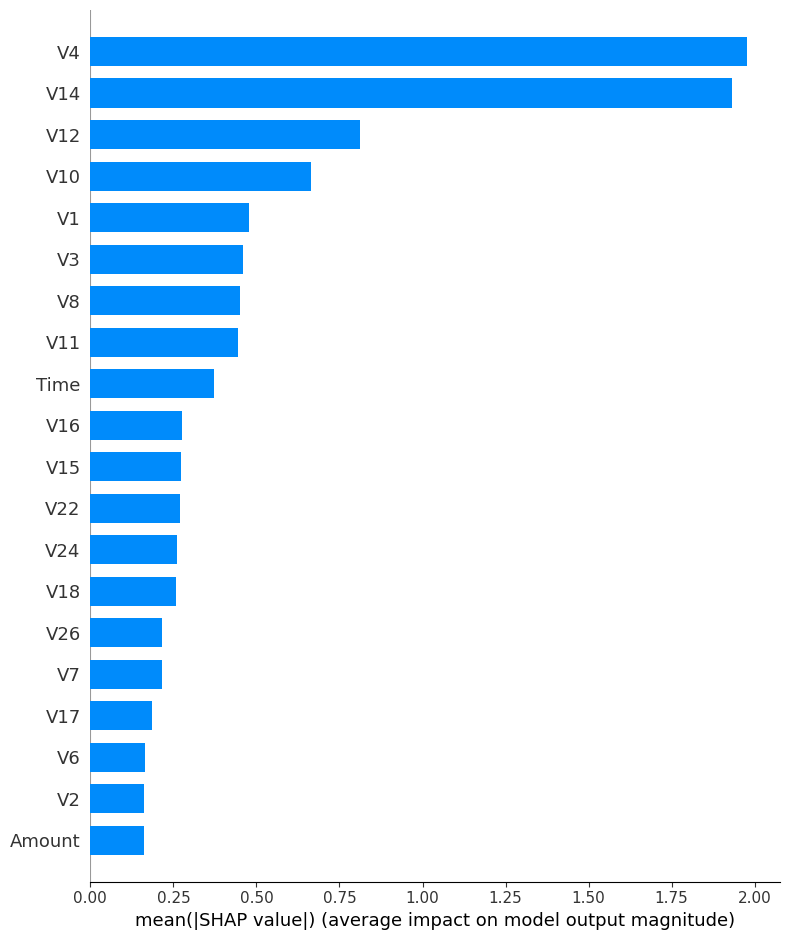

[PLOT] SHAP Beeswarm (global impact)


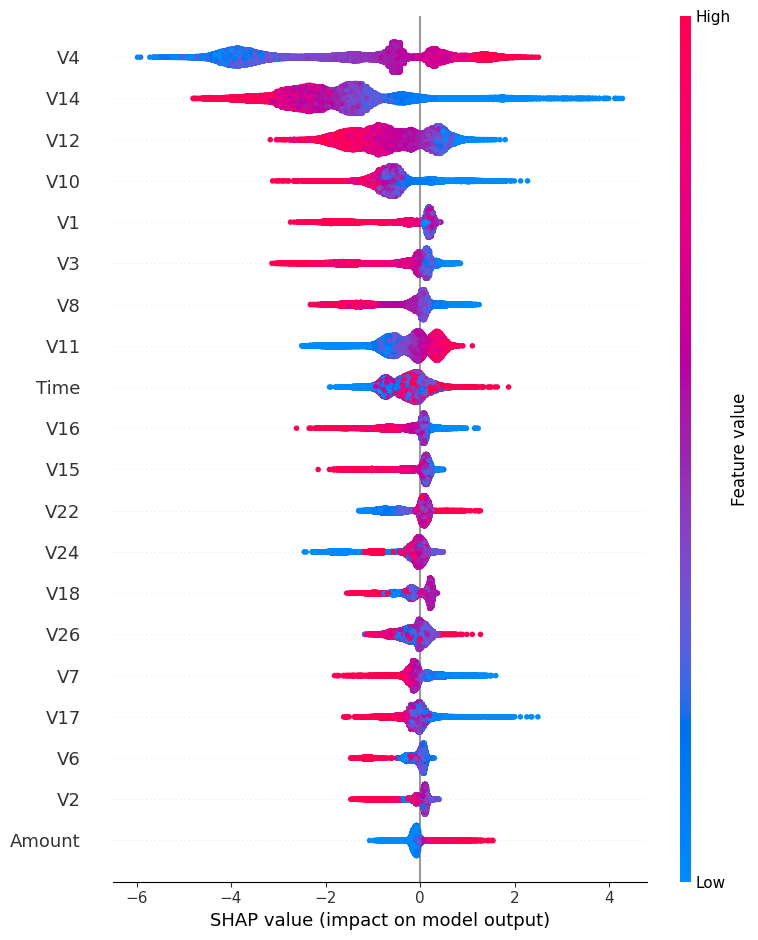

[INFO] Explaining sample index: 7299


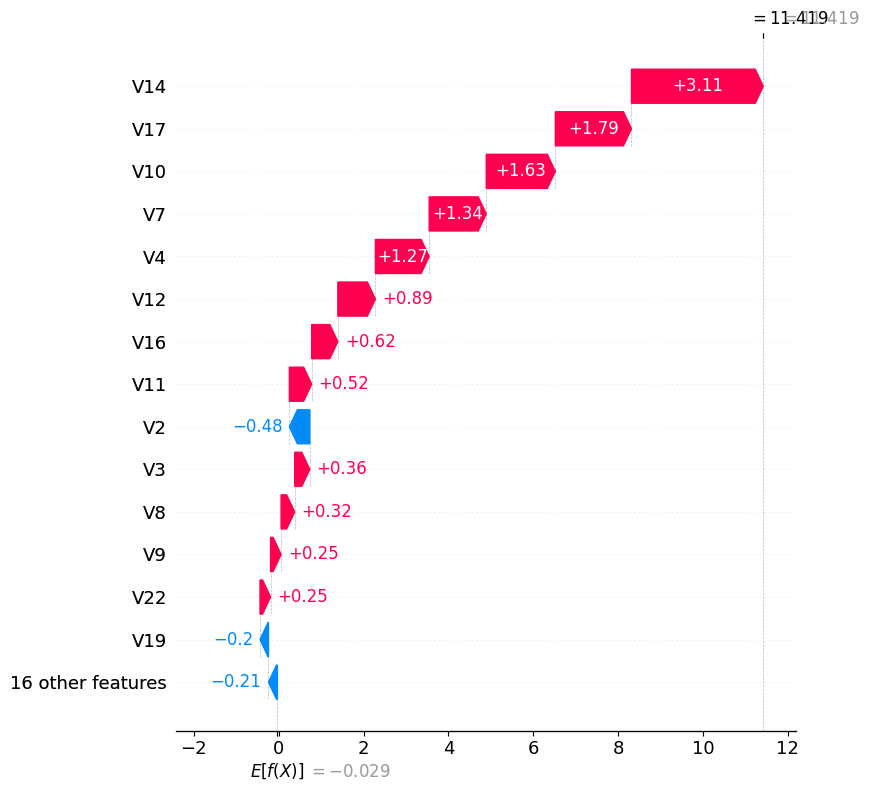

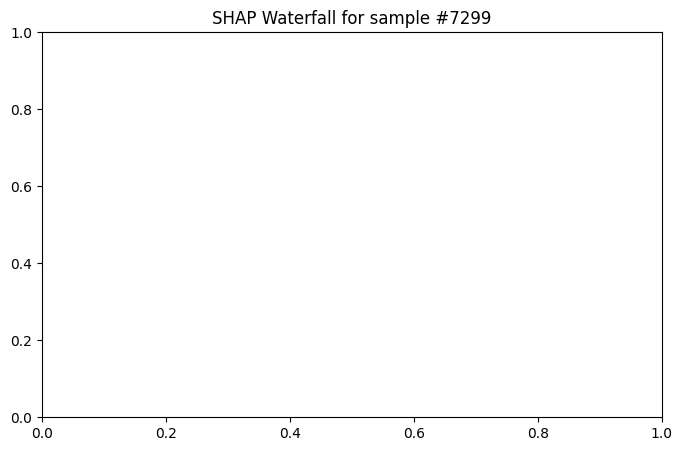

[DONE] SHAP explainability generated: global (bar + beeswarm) and local (force + waterfall).


In [ ]:
# === ONE-CELL SHAP EXPLAINABILITY FOR XGBOOST ===
# Installs, imports, model loading/fallback, SHAP global + local plots

# 1) Install
import sys, subprocess, os, warnings
warnings.filterwarnings("ignore")
def pip_install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
for pkg in ["shap", "xgboost", "joblib"]:
    try:
        __import__(pkg if pkg != "joblib" else "joblib")
    except Exception:
        pip_install(pkg)

# 2) Imports
import numpy as np
import pandas as pd
import shap
import joblib
import matplotlib.pyplot as plt
from pathlib import Path

# Avoid interactive style issues
plt.rcParams.update({"figure.figsize": (8, 5)})

try:
    from xgboost import XGBClassifier
except Exception as e:
    raise RuntimeError("XGBoost import failed. Please ensure it installed correctly.") from e

# 3) Small helpers
def is_dataframe(X):
    return isinstance(X, pd.DataFrame)

def to_dataframe(X, like_df=None):
    """Ensure we always have a DataFrame with column names."""
    if is_dataframe(X):
        return X
    cols = None
    if is_dataframe(like_df):
        cols = list(like_df.columns)
    elif hasattr(like_df, "shape"):
        cols = [f"feat_{i}" for i in range(like_df.shape[1])]
    else:
        cols = [f"feat_{i}" for i in range(X.shape[1])]
    return pd.DataFrame(X, columns=cols)

def class_ratio(y):
    # returns (neg, pos) counts
    y_arr = y.values if isinstance(y, pd.Series) else y
    neg = np.sum(y_arr == 0)
    pos = np.sum(y_arr == 1)
    return neg, pos

def choose_fraud_index(X_test_df, y_test_series, model):
    """Pick a good example to explain:
    - prefer a true fraud with high predicted prob
    - else pick the highest predicted probability overall
    """
    proba = model.predict_proba(X_test_df)[:, 1] if hasattr(model, "predict_proba") else model.predict(X_test_df)
    if y_test_series is not None:
        # indices with true fraud
        fraud_idx = np.where((y_test_series.values if isinstance(y_test_series, pd.Series) else y_test_series) == 1)[0]
        if len(fraud_idx) > 0:
            # among frauds, choose the highest predicted prob
            best = fraud_idx[np.argmax(proba[fraud_idx])]
            return int(best)
    # fallback: overall best prob
    return int(np.argmax(proba))

# 4) Fetch data objects from the notebook namespace
# Expecting X_train, X_test, y_train, y_test to already exist in the notebook.
# If they don't, this will raise a helpful error.
globals_ = globals()
required = ["X_train", "X_test", "y_train", "y_test"]
missing = [v for v in required if v not in globals_]
if missing:
    raise NameError(f"Missing variables in notebook: {missing}. Please ensure you have X_train, X_test, y_train, y_test defined.")

X_train_raw, X_test_raw = globals_["X_train"], globals_["X_test"]
y_train_raw, y_test_raw = globals_["y_train"], globals_["y_test"]

# Normalize to DataFrame/Series for SHAP naming and plotting
X_train_df = to_dataframe(X_train_raw)
X_test_df  = to_dataframe(X_test_raw, like_df=X_train_df)
y_train_sr = pd.Series(y_train_raw) if not isinstance(y_train_raw, pd.Series) else y_train_raw
y_test_sr  = pd.Series(y_test_raw)  if not isinstance(y_test_raw, pd.Series)  else y_test_raw

# 5) Get an XGBoost model:
# Priority 1: use existing 'xgb_model' from the notebook
# Priority 2: try to load 'best_xgb.joblib' from common paths
# Priority 3: quick fallback training
xgb = None
if "xgb_model" in globals_ and globals_["xgb_model"] is not None:
    xgb = globals_["xgb_model"]
else:
    # try a few likely paths
    candidate_paths = [
        Path("best_xgb.joblib"),
        Path("./models/best_xgb.joblib"),
        Path("/mnt/data/best_xgb.joblib")
    ]
    loaded = False
    for p in candidate_paths:
        if p.exists():
            try:
                xgb = joblib.load(p)
                loaded = True
                print(f"[INFO] Loaded model from: {p}")
                break
            except Exception:
                pass
    if not loaded:
        # quick fallback training
        neg, pos = class_ratio(y_train_sr)
        scale_pos_weight = (neg / max(pos, 1)) if pos > 0 else 1.0
        print("[INFO] No existing XGB model found. Training a quick fallback (tune later for best results).")
        xgb = XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.08,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            objective="binary:logistic",
            eval_metric="auc",
            tree_method="hist",
            scale_pos_weight=scale_pos_weight,
            random_state=42,
            n_jobs=-1,
        )
        xgb.fit(X_train_df, y_train_sr)

# 6) Build SHAP explainer + values
# Note: TreeExplainer is ideal for tree models like XGBoost
print("[INFO] Computing SHAP values… (this can take a minute on large data)")
shap.initjs()  # enables JS-based plots like force plot in notebooks
explainer = shap.TreeExplainer(xgb)
# For XGBoost >= 1.7, pass the raw values; explainer handles internally
shap_values = explainer.shap_values(X_test_df)

# 7) GLOBAL EXPLANATIONS
# Bar chart of mean(|SHAP|) feature importance
print("[PLOT] SHAP Feature Importance (bar)")
shap.summary_plot(shap_values, X_test_df, plot_type="bar", show=True)

# Beeswarm for directionality & distribution
print("[PLOT] SHAP Beeswarm (global impact)")
shap.summary_plot(shap_values, X_test_df, show=True)

# 8) LOCAL EXPLANATION for one test sample (prefer a true fraud with high predicted probability)
idx = choose_fraud_index(X_test_df, y_test_sr, xgb)
x_row = X_test_df.iloc[idx]

print(f"[INFO] Explaining sample index: {idx}")
# Force plot (JS) — good for notebooks
try:
    display(shap.force_plot(explainer.expected_value, shap_values[idx], x_row))
except Exception as e:
    print(f"[WARN] force_plot display issue: {e}")

# Waterfall plot (matplotlib) — robust static local view
try:
    shap.plots._waterfall.waterfall_legacy(explainer.expected_value, shap_values[idx], feature_names=list(X_test_df.columns), max_display=15)
    plt.title(f"SHAP Waterfall for sample #{idx}")
    plt.show()
except Exception as e:
    print(f"[WARN] Waterfall plot issue: {e}")

print("[DONE] SHAP explainability generated: global (bar + beeswarm) and local (force + waterfall).")


In [ ]:
import os, json
print("Has best_xgb.joblib?        ", os.path.exists("/content/best_xgb.joblib"))
print("Has best_xgb_threshold.json?", os.path.exists("/content/best_xgb_threshold.json"))
# optional:
print("Has amount_scaler.joblib?   ", os.path.exists("/content/amount_scaler.joblib"))


Has best_xgb.joblib?         True
Has best_xgb_threshold.json? True
Has amount_scaler.joblib?    False


In [ ]:
import joblib, pandas as pd, os

model = joblib.load("/content/best_xgb.joblib")
feature_order = None
try:
    feature_order = model.get_booster().feature_names
except Exception:
    pass
if not feature_order:
    feature_order = ["Time"] + [f"V{i}" for i in range(1,29)] + ["Amount"]

# one empty row you can fill in later:
df = pd.DataFrame(columns=feature_order)
df.to_csv("/content/template_transactions.csv", index=False)
print("Saved:", "/content/template_transactions.csv")


Saved: /content/template_transactions.csv


In [ ]:
import joblib, pandas as pd, os

# Get feature order from model if possible; else fallback
model = joblib.load("/content/best_xgb.joblib")
try:
    feature_order = model.get_booster().feature_names
except Exception:
    feature_order = ["Time"] + [f"V{i}" for i in range(1,29)] + ["Amount"]

# make one example row (all zeros except Time/Amount)
row = {c: 0.0 for c in feature_order}
if "Time" in row: row["Time"] = 50000
if "Amount" in row: row["Amount"] = 123.45

df = pd.DataFrame([row], columns=feature_order)
df.to_csv("/content/template_transactions.csv", index=False)
print("Saved template at /content/template_transactions.csv with columns:\n", feature_order)


Saved template at /content/template_transactions.csv with columns:
 ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


In [ ]:
!pip install -q gradio joblib pandas scikit-learn xgboost


In [ ]:
%%writefile /content/app.py
# app.py — Credit Card Fraud Detection (Gradio app with CSV upload + download)
# Place this file in /content/ alongside:
#   - best_xgb.joblib                 (from Step 2)
#   - best_xgb_threshold.json         (from Step 3)
#   - amount_scaler.joblib  (optional, only if you saved it during training)

import os, json, warnings, time
warnings.filterwarnings("ignore")

import gradio as gr
import pandas as pd
import numpy as np
import joblib

# ---------- Paths ----------
MODEL_PATH  = "/content/best_xgb.joblib"
THRESH_PATH = "/content/best_xgb_threshold.json"
SCALER_PATH = "/content/amount_scaler.joblib"   # optional

# ---------- Load artifacts ----------
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError("best_xgb.joblib not found in /content/. Re-run Step 2 to save it there.")
if not os.path.exists(THRESH_PATH):
    raise FileNotFoundError("best_xgb_threshold.json not found in /content/. Re-run Step 3 to save it there.")

model = joblib.load(MODEL_PATH)
with open(THRESH_PATH, "r") as f:
    threshold = float(json.load(f)["threshold"])

amount_scaler = joblib.load(SCALER_PATH) if os.path.exists(SCALER_PATH) else None

# ---------- Determine feature order ----------
# Prefer model booster feature names; else fallback to standard Kaggle order
feature_order = None
try:
    booster = model.get_booster()
    feature_order = booster.feature_names  # e.g., ["Time","V1",...,"V28","Amount"]
except Exception:
    pass

if not feature_order:
    feature_order = ["Time"] + [f"V{i}" for i in range(1, 29)] + ["Amount"]

REQUIRED_COLS = feature_order[:]  # exact order used in training

# ---------- Helpers ----------
def _preprocess(df: pd.DataFrame) -> pd.DataFrame:
    """Apply same preprocessing as training (e.g., Amount scaling) and column ordering."""
    df = df.copy()
    # exact column order
    df = df[REQUIRED_COLS]
    # optional: scale Amount if scaler exists
    if amount_scaler is not None and "Amount" in df.columns:
        df["Amount"] = amount_scaler.transform(df[["Amount"]])
    return df

def _label_probs(prob: float) -> dict:
    """Return dict for gr.Label (class->prob)."""
    return {"Fraud": float(prob), "Not Fraud": float(1.0 - prob)}

def _error_df(msg: str) -> pd.DataFrame:
    """DataFrame wrapper for error messages (so Dataframe output never crashes)."""
    return pd.DataFrame({"error": [msg]})

# ---------- Single transaction predict ----------
def predict_single(amount, time_val, *features):
    # Build row in REQUIRED_COLS order
    vals = {"Amount": amount, "Time": time_val}
    for i in range(1, 29):
        vals[f"V{i}"] = features[i - 1] if i - 1 < len(features) else 0.0
    row = [vals[c] for c in REQUIRED_COLS]

    X = pd.DataFrame([row], columns=REQUIRED_COLS)
    Xp = _preprocess(X)

    prob = float(model.predict_proba(Xp)[:, 1][0])
    return _label_probs(prob)

# ---------- CSV prediction (hardened) ----------
def predict_csv(file_path):
    if file_path is None or (isinstance(file_path, str) and not os.path.exists(file_path)):
        return _error_df("No file found. Please upload a CSV."), None

    try:
        df = pd.read_csv(file_path)

        # 1) Validate columns
        missing = [c for c in REQUIRED_COLS if c not in df.columns]
        if missing:
            return _error_df(
                f"Missing columns: {missing}\nExpected EXACT columns (order matters): {REQUIRED_COLS}"
            ), None

        if df.empty:
            return _error_df("CSV has headers but no rows. Add at least one row."), None

        # 2) Keep only required columns and coerce to numeric
        df_req = df[REQUIRED_COLS].copy()
        for c in REQUIRED_COLS:
            df_req[c] = pd.to_numeric(df_req[c], errors="coerce")

        # 3) Drop rows that are completely NaN in required columns
        valid_mask = ~df_req.isna().all(axis=1)
        if valid_mask.sum() == 0:
            return _error_df("All rows contain non-numeric/NaN values. Ensure values are numbers."), None

        df_req  = df_req[valid_mask]
        original = df.loc[df_req.index].copy()

        # 4) Fill partial NaNs with 0.0 (or change to your training policy)
        df_req = df_req.fillna(0.0)

        # 5) Preprocess and predict
        Xp    = _preprocess(df_req)
        probs = model.predict_proba(Xp)[:, 1]
        preds = (probs >= threshold).astype(int)

        out = original.copy()
        out["Fraud_Probability"] = probs
        out["Prediction"] = np.where(preds == 1, "Fraud", "Not Fraud")

        # 6) Save full predictions for download
        out_path = f"/content/predictions_{int(time.time())}.csv"
        out.to_csv(out_path, index=False)

        # 7) Preview (first 20 rows)
        preview_cols = [c for c in ["Time","Amount","V1","V2","V3","V4","V5"] if c in out.columns]
        preview_cols += ["Fraud_Probability", "Prediction"]
        preview = out[preview_cols].head(20)

        return preview, out_path

    except Exception as e:
        return _error_df(f"Error while processing CSV: {e}"), None

# ---------- Gradio UI ----------
single_inputs = [
    gr.Number(label="Transaction Amount", value=100.0),
    gr.Number(label="Transaction Time (seconds)", value=50000),
] + [gr.Number(label=f"V{i}", value=0.0) for i in range(1, 29)]

single_output = gr.Label(label="Fraud Prediction")

manual_ui = gr.Interface(
    fn=predict_single,
    inputs=single_inputs,
    outputs=single_output,
    title="💳 Credit Card Fraud Detection — Single Transaction",
    description=(
        "Enter Amount, Time, and V1–V28. "
        "Uses your trained XGBoost model and tuned threshold. "
        f"Expected feature order: {REQUIRED_COLS}"
    ),
    allow_flagging="never"
)

csv_ui = gr.Interface(
    fn=predict_csv,
    inputs=gr.File(
        label="Upload CSV (columns MUST exactly match training)",
        file_types=[".csv"],
        type="filepath"
    ),
    outputs=[
        gr.Dataframe(label="Preview / Messages"),
        gr.File(label="Download full predictions CSV")
    ],
    title="💳 Credit Card Fraud Detection — CSV Upload",
    description=(
        "Upload a CSV with EXACT columns (order matters): "
        f"{REQUIRED_COLS}\n"
        "The left pane shows a preview or an error message. Use the download to get full predictions."
    ),
    allow_flagging="never"
)

demo = gr.TabbedInterface([manual_ui, csv_ui], ["Single Transaction", "CSV Upload"])

if __name__ == "__main__":
    # share=True is required in Colab to expose a public link
    demo.launch(share=True)


Writing /content/app.py


In [ ]:
import numpy as np
from sklearn.metrics import roc_auc_score

def robustness_with_noise(model, X_test, y_test, noise_level=0.01, n_trials=5):
    base_score = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    print(f"Base ROC-AUC: {base_score:.4f}")

    noisy_scores = []
    for i in range(n_trials):
        X_noisy = X_test + noise_level * np.random.normal(0, 1, X_test.shape)
        noisy_score = roc_auc_score(y_test, model.predict_proba(X_noisy)[:, 1])
        noisy_scores.append(noisy_score)
        print(f"Trial {i+1}: ROC-AUC with noise = {noisy_score:.4f}")

    print(f"\nMean ROC-AUC with noise: {np.mean(noisy_scores):.4f}")
    print(f"Std deviation: {np.std(noisy_scores):.4f}")
    return noisy_scores


In [ ]:
robustness_with_noise(best_model, X_test, y_test, noise_level=0.02, n_trials=10)


Base ROC-AUC: 0.9821
Trial 1: ROC-AUC with noise = 0.9814
Trial 2: ROC-AUC with noise = 0.9831
Trial 3: ROC-AUC with noise = 0.9834
Trial 4: ROC-AUC with noise = 0.9820
Trial 5: ROC-AUC with noise = 0.9816
Trial 6: ROC-AUC with noise = 0.9824
Trial 7: ROC-AUC with noise = 0.9837
Trial 8: ROC-AUC with noise = 0.9838
Trial 9: ROC-AUC with noise = 0.9837
Trial 10: ROC-AUC with noise = 0.9843

Mean ROC-AUC with noise: 0.9829
Std deviation: 0.0010


[np.float64(0.981398330998128),
 np.float64(0.9830919530164344),
 np.float64(0.9833873229933504),
 np.float64(0.981993198235963),
 np.float64(0.9815625251225981),
 np.float64(0.9823897763945195),
 np.float64(0.9836719261424323),
 np.float64(0.9837553690581465),
 np.float64(0.9836572114777256),
 np.float64(0.9843208069665683)]

In [ ]:
from sklearn.datasets import make_classification

def synthetic_check(model, n_samples=1000):
    # Generate synthetic dataset
    X_syn, y_syn = make_classification(n_samples=n_samples, n_features=X_test.shape[1],
                                       n_informative=10, n_redundant=2, n_clusters_per_class=2,
                                       weights=[0.99], random_state=42)

    preds = model.predict(X_syn)
    probas = model.predict_proba(X_syn)[:, 1]

    auc = roc_auc_score(y_syn, probas)
    print(f"Synthetic Data ROC-AUC: {auc:.4f}")

    fraud_detected = sum(preds[y_syn == 1]) / sum(y_syn)
    print(f"Fraud detection rate on synthetic data: {fraud_detected:.2%}")

    return auc, fraud_detected


In [ ]:
!python /content/app.py

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://4d24f1e44f1655004b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
Keyboard interruption in main thread... closing server.
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 3158, in block_thread
    time.sleep(0.1)
KeyboardInterrupt

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/content/app.py", line 181, in <module>
    demo.launch(share=True)
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 3055, in launch
    self.block_thread()
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 3162, in block_thread
    self.server.close()
  File "/usr/local/lib/python3.12/dist-package

In [ ]:
# --- Random Forest with Random Oversampling: Top Features ---

import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances from trained Random Forest (rf_ros)
importances = rf_ros.feature_importances_
feature_names = X.columns

# Create DataFrame
feat_imp_ros = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Display Top 10 Features
print("Top 10 Features - Random Forest (with Random Oversampling):")
print(feat_imp_ros.head(10))

# Plot Top 10 Features
top_features = feat_imp_ros.head(10)
plt.figure(figsize=(8,6))
plt.barh(top_features["Feature"], top_features["Importance"], color="skyblue")
plt.gca().invert_yaxis()
plt.title("Top 10 Features - Random Forest with Random Oversampling", fontsize=14)
plt.xlabel("Feature Importance", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.show()


NameError: name 'rf_ros' is not defined